# Life Insurance Claims Analysis and Prediction

## 1. Introduction

This Jupyter notebook presents a comprehensive machine learning project focused on analyzing life insurance claims data. The objective is to understand the various factors influencing claims processing and outcomes, and to build a predictive model for `claims_paid_amt`. This analysis will cover data loading, exploratory data analysis (EDA), data preprocessing, feature engineering, model selection, training, evaluation, hyperparameter tuning, and insightful conclusions.

**Project Goal**: To predict the `claims_paid_amt` (amount of claims paid) using the provided insurance claims dataset. This is a regression problem.

**Architecture Diagram Placeholder**:
Please create an architecture diagram using https://app.diagrams.net/ and download it as an .svg file.
The diagram should illustrate the flow of data from ingestion, through EDA, preprocessing, model training, evaluation, hyperparameter tuning, to final model saving and prediction.

**Key Steps**:
1.  **Data Loading**: Ingest the dataset from a CSV file.
2.  **Exploratory Data Analysis (EDA)**: Understand data distribution, identify missing values, outliers, and relationships.
3.  **Data Preprocessing**: Clean and transform the data, handle missing values, outliers, and prepare features for modeling.
4.  **Feature Engineering**: Create new features to enhance model performance.
5.  **Model Building**: Train suitable regression models.
6.  **Evaluation**: Assess model performance using appropriate metrics.
7.  **Hyperparameter Tuning**: Optimize model parameters for best performance.
8.  **Insights & Conclusion**: Summarize findings and future recommendations.


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging
import os
import json
import pickle # For saving the model

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- Setup Logging ---
log_dir = 'ml_logs'
if not os.path.exists(log_dir):
    os.makedirs(log_dir)

logging.basicConfig(level=logging.INFO,
                    format='%(asctime)s - %(levelname)s - %(message)s',
                    handlers=[
                        logging.FileHandler(os.path.join(log_dir, 'ml_project.log')),
                        logging.StreamHandler()
                    ])

logger = logging.getLogger(__name__)

# Create artifacts directory
artifacts_dir = 'artifacts'
if not os.path.exists(artifacts_dir):
    os.makedirs(artifacts_dir)
    logger.info(f"Created artifacts directory at: {artifacts_dir}")

logger.info("Notebook setup complete. Logging initialized and directories created.")

# # Sample data provided in the problem description
# sample_data = [{'life_insurer': 'ABSL', 'year': '2021-22', 'claims_pending_start_no': 7, 'claims_pending_start_amt': 1.6944806650000277, 'claims_intimated_no': 13518, 'claims_intimated_amt': 675.2559034569999, 'total_claims_no': 13525, 'total_claims_amt': 676.950384122, 'claims_paid_no': 13470, 'claims_paid_amt': 666.77329184, 'claims_repudiated_no': 52, 'claims_repudiated_amt': 7.782922282, 'claims_rejected_no': 0, 'claims_rejected_amt': 0.0, 'claims_unclaimed_no': 0, 'claims_unclaimed_amt': 0.0, 'claims_pending_end_no': 3, 'claims_pending_end_amt': 2.39416999999999, 'claims_paid_ratio_no': 0.9959334565619224, 'claims_paid_ratio_amt': 0.9849662655924192, 'claims_repudiated_rejected_ratio_no': 0.0038447319778188, 'claims_repudiated_rejected_ratio_amt': 0.0114970350332165, 'claims_pending_ratio_no': 0.0002218114602587, 'claims_pending_ratio_amt': 0.0035366993743643, 'category': 'Group Death Claims'}, {'life_insurer': 'Aegon', 'year': '2021-22', 'claims_pending_start_no': 0, 'claims_pending_start_amt': 0.0, 'claims_intimated_no': 361, 'claims_intimated_amt': 76.06, 'total_claims_no': 361, 'total_claims_amt': 76.06, 'claims_paid_no': 361, 'claims_paid_amt': 76.03, 'claims_repudiated_no': 0, 'claims_repudiated_amt': 0.0, 'claims_rejected_no': 0, 'claims_rejected_amt': 0.0, 'claims_unclaimed_no': 0, 'claims_unclaimed_amt': 0.0, 'claims_pending_end_no': 0, 'claims_pending_end_amt': 0.0300000000000011, 'claims_paid_ratio_no': 1.0, 'claims_paid_ratio_amt': 0.9996055745464107, 'claims_repudiated_rejected_ratio_no': 0.0, 'claims_repudiated_rejected_ratio_amt': 0.0, 'claims_pending_ratio_no': 0.0, 'claims_pending_ratio_amt': 0.0003944254535892, 'category': 'Group Death Claims'}, {'life_insurer': 'Ageas', 'year': '2021-22', 'claims_pending_start_no': 15, 'claims_pending_start_amt': 4.806673751399991, 'claims_intimated_no': 481, 'claims_intimated_amt': 100.8266249033, 'total_claims_no': 496, 'total_claims_amt': 105.63329865469998, 'claims_paid_no': 446, 'claims_paid_amt': 89.0313663928, 'claims_repudiated_no': 45, 'claims_repudiated_amt': 15.1815667019, 'claims_rejected_no': 0, 'claims_rejected_amt': 0.0, 'claims_unclaimed_no': 0, 'claims_unclaimed_amt': 0.0, 'claims_pending_end_no': 5, 'claims_pending_end_amt': 1.4203655599999898, 'claims_paid_ratio_no': 0.8991935483870968, 'claims_paid_ratio_amt': 0.8428342911436543, 'claims_repudiated_rejected_ratio_no': 0.0907258064516129, 'claims_repudiated_rejected_ratio_amt': 0.1437195173798969, 'claims_pending_ratio_no': 0.0100806451612903, 'claims_pending_ratio_amt': 0.0134461914764487, 'category': 'Group Death Claims'}, {'life_insurer': 'Aviva', 'year': '2021-22', 'claims_pending_start_no': 0, 'claims_pending_start_amt': 0.0, 'claims_intimated_no': 1347, 'claims_intimated_amt': 68.63594090000001, 'total_claims_no': 1347, 'total_claims_amt': 68.6309604, 'claims_paid_no': 1345, 'claims_paid_amt': 68.4839409, 'claims_repudiated_no': 1, 'claims_repudiated_amt': 0.15, 'claims_rejected_no': 1, 'claims_rejected_amt': 0.002, 'claims_unclaimed_no': 0, 'claims_unclaimed_amt': 0.0, 'claims_pending_end_no': 0, 'claims_pending_end_amt': -0.0049804999999868, 'claims_paid_ratio_no': 0.9985152190051968, 'claims_paid_ratio_amt': 0.997857825402076, 'claims_repudiated_rejected_ratio_no': 0.0014847809948032, 'claims_repudiated_rejected_ratio_amt': 0.0022147438869294, 'claims_pending_ratio_no': 0.0, 'claims_pending_ratio_amt': -7.256928900541529e-05, 'category': 'Group Death Claims'}, {'life_insurer': 'Baj Alz', 'year': '2021-22', 'claims_pending_start_no': 85, 'claims_pending_start_amt': 6.8678338, 'claims_intimated_no': 193169, 'claims_intimated_amt': 1578.2510421906031, 'total_claims_no': 193254, 'total_claims_amt': 1585.118875990603, 'claims_paid_no': 192902, 'claims_paid_amt': 1553.4667594367572, 'claims_repudiated_no': 181, 'claims_repudiated_amt': 22.8570066, 'claims_rejected_no': 0, 'claims_rejected_amt': 0.0, 'claims_unclaimed_no': 0, 'claims_unclaimed_amt': 0.0, 'claims_pending_end_no': 171, 'claims_pending_end_amt': 8.79510995384587, 'claims_paid_ratio_no': 0.998178562927546, 'claims_paid_ratio_amt': 0.9800317080105015, 'claims_repudiated_rejected_ratio_no': 0.0009365912219151, 'claims_repudiated_rejected_ratio_amt': 0.0144197428635853, 'claims_pending_ratio_no': 0.0008848458505386, 'claims_pending_ratio_amt': 0.005548549125913, 'category': 'Group Death Claims'}, {'life_insurer': 'Bharti Axa', 'year': '2021-22', 'claims_pending_start_no': 5, 'claims_pending_start_amt': 1.193382143, 'claims_intimated_no': 1802, 'claims_intimated_amt': 145.061780234, 'total_claims_no': 1807, 'total_claims_amt': 146.255162377, 'claims_paid_no': 1779, 'claims_paid_amt': 143.27315592800002, 'claims_repudiated_no': 28, 'claims_repudiated_amt': 2.982006449, 'claims_rejected_no': 0, 'claims_rejected_amt': 0.0, 'claims_unclaimed_no': 0, 'claims_unclaimed_amt': 0.0, 'claims_pending_end_no': 0, 'claims_pending_end_amt': -1.7763568394002505e-14, 'claims_paid_ratio_no': 0.9845047039291644, 'claims_paid_ratio_amt': 0.9796109320140556, 'claims_repudiated_rejected_ratio_no': 0.0154952960708356, 'claims_repudiated_rejected_ratio_amt': 0.0203890679859444, 'claims_pending_ratio_no': 0.0, 'claims_pending_ratio_amt': -1.2145600951994834e-16, 'category': 'Group Death Claims'}, {'life_insurer': 'Can HSBC', 'year': '2021-22', 'claims_pending_start_no': 1, 'claims_pending_start_amt': 0.02, 'claims_intimated_no': 10551, 'claims_intimated_amt': 374.0344093100282, 'total_claims_no': 10552, 'total_claims_amt': 374.0544093100282, 'claims_paid_no': 10466, 'claims_paid_amt': 361.1798822429445, 'claims_repudiated_no': 86, 'claims_repudiated_amt': 12.874527067, 'claims_rejected_no': 0, 'claims_rejected_amt': 0.0, 'claims_unclaimed_no': 0, 'claims_unclaimed_amt': 0.0, 'claims_pending_end_no': 0, 'claims_pending_end_amt': 8.370371062937919e-11, 'claims_paid_ratio_no': 0.9918498862774828, 'claims_paid_ratio_amt': 0.9655811380733842, 'claims_repudiated_rejected_ratio_no': 0.008150113722517, 'claims_repudiated_rejected_ratio_amt': 0.034418861926392, 'claims_pending_ratio_no': 0.0, 'claims_pending_ratio_amt': 2.2377415837385013e-13, 'category': 'Group Death Claims'}, {'life_insurer': 'Edelws', 'year': '2021-22', 'claims_pending_start_no': 0, 'claims_pending_start_amt': 0.0, 'claims_intimated_no': 2314, 'claims_intimated_amt': 82.88322733199999, 'total_claims_no': 2314, 'total_claims_amt': 82.88322733199999, 'claims_paid_no': 2300, 'claims_paid_amt': 81.616184635, 'claims_repudiated_no': 12, 'claims_repudiated_amt': 1.141542697, 'claims_rejected_no': 0, 'claims_rejected_amt': 0.0, 'claims_unclaimed_no': 0, 'claims_unclaimed_amt': 0.0, 'claims_pending_end_no': 2, 'claims_pending_end_amt': 0.1254999999999937, 'claims_paid_ratio_no': 0.9939498703543648, 'claims_paid_ratio_amt': 0.9847129179475036, 'claims_repudiated_rejected_ratio_no': 0.0051858254105445, 'claims_repudiated_rejected_ratio_amt': 0.0137729035625916, 'claims_pending_ratio_no': 0.0008643042350907, 'claims_pending_ratio_amt': 0.0015141784899046, 'category': 'Group Death Claims'}, {'life_insurer': 'Exide', 'year': '2021-22', 'claims_pending_start_no': 0, 'claims_pending_start_amt': 0.0, 'claims_intimated_no': 14363, 'claims_intimated_amt': 324.17798300000004, 'total_claims_no': 14363, 'total_claims_amt': 324.17798300000004, 'claims_paid_no': 14363, 'claims_paid_amt': 324.177983, 'claims_repudiated_no': 0, 'claims_repudiated_amt': 0.0, 'claims_rejected_no': 0, 'claims_rejected_amt': 0.0, 'claims_unclaimed_no': 0, 'claims_unclaimed_amt': 0.0, 'claims_pending_end_no': 0, 'claims_pending_end_amt': 5.684341886080804e-14, 'claims_paid_ratio_no': 1.0, 'claims_paid_ratio_amt': 0.9999999999999998, 'claims_repudiated_rejected_ratio_no': 0.0, 'claims_repudiated_rejected_ratio_amt': 0.0, 'claims_pending_ratio_no': 0.0, 'claims_pending_ratio_amt': 1.7534632776343731e-16, 'category': 'Group Death Claims'}, {'life_insurer': 'Fut Genli', 'year': '2021-22', 'claims_pending_start_no': 3, 'claims_pending_start_amt': 0.379, 'claims_intimated_no': 1644, 'claims_intimated_amt': 226.2476827326923, 'total_claims_no': 1647, 'total_claims_amt': 226.62668273269236, 'claims_paid_no': 1575, 'claims_paid_amt': 216.40541773269229, 'claims_repudiated_no': 69, 'claims_repudiated_amt': 9.502265, 'claims_rejected_no': 1, 'claims_rejected_amt': 0.0, 'claims_unclaimed_no': 2, 'claims_unclaimed_amt': 0.719, 'claims_pending_end_no': 0, 'claims_pending_end_amt': 4.5630166312093934e-14, 'claims_paid_ratio_no': 0.9562841530054644, 'claims_paid_ratio_amt': 0.9548982278840656, 'claims_repudiated_rejected_ratio_no': 0.0425015179113539, 'claims_repudiated_rejected_ratio_amt': 0.0419291536434303, 'claims_pending_ratio_no': 0.0, 'claims_pending_ratio_amt': 2.01345074471725e-16, 'category': 'Group Death Claims'}]

# # Create a dummy CSV file from sample_data for demonstration purposes
# data_dir = 'data'
# if not os.path.exists(data_dir):
#     os.makedirs(data_dir)
#     logger.info(f"Created data directory at: {data_dir}")

# csv_file_path = os.path.join(data_dir, 'life_insurance_claims.csv')
# pd.DataFrame(sample_data).to_csv(csv_file_path, index=False)
# logger.info(f"Dummy CSV file created at: {csv_file_path}")


2026-02-05 14:16:56,157 - INFO - Notebook setup complete. Logging initialized and directories created.


## 2. Data Loading

In this section, we will load the dataset from the specified CSV file. Robust error handling is included to manage potential issues during file loading, such as a non-existent file.


In [23]:
# Define the path to the dataset
# NOTE: In a real scenario, this would be your full dataset file path.
# For this notebook, we've created a dummy CSV from the sample data.
dataset_path = r"C:\Users\Priya Bhaskar\OneDrive\Documents\ml_agent_repo_1\MLAgent-automation\data\cleaned_group_death_claims.csv"

try:
    df = pd.read_csv(dataset_path)
    logger.info(f"Dataset loaded successfully from {dataset_path}. Shape: {df.shape}")
except FileNotFoundError:
    logger.error(f"Error: The dataset file was not found at {dataset_path}. Please check the path.")
    df = pd.DataFrame() # Initialize an empty DataFrame to prevent further errors
except Exception as e:
    logger.error(f"An unexpected error occurred during data loading: {e}")
    df = pd.DataFrame()

# Display the first few rows of the dataset
if not df.empty:
    print("First 5 rows of the dataset:")
    print(df.head())
else:
    print("DataFrame is empty due to loading error.")


2026-02-05 14:18:13,613 - INFO - Dataset loaded successfully from C:\Users\Priya Bhaskar\OneDrive\Documents\ml_agent_repo_1\MLAgent-automation\data\cleaned_group_death_claims.csv. Shape: (149, 25)


First 5 rows of the dataset:
  life_insurer     year  claims_pending_start_no  claims_pending_start_amt  \
0         ABSL  2021-22                        7                  1.694481   
1        Aegon  2021-22                        0                  0.000000   
2        Ageas  2021-22                       15                  4.806674   
3        Aviva  2021-22                        0                  0.000000   
4      Baj Alz  2021-22                       85                  6.867834   

   claims_intimated_no  claims_intimated_amt  total_claims_no  \
0                13518            675.255903            13525   
1                  361             76.060000              361   
2                  481            100.826625              496   
3                 1347             68.635941             1347   
4               193169           1578.251042           193254   

   total_claims_amt  claims_paid_no  claims_paid_amt  ...  \
0        676.950384           13470       666.7732

## 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is a crucial step to understand the dataset's characteristics, identify patterns, anomalies, and relationships.

### Initial Data Inspection

We'll start by checking the basic information about the dataset, including its shape, column names, data types, and a summary of numerical features.


In [24]:
if not df.empty:
    logger.info("Starting initial EDA.")
    print("\nDataset Info:")
    df.info()

    print("\nStatistical Summary of Numerical Columns:")
    print(df.describe())

    print("\nNumber of unique values in each column:")
    print(df.nunique())

    print("\nCategorical columns and their unique values:")
    for col in df.select_dtypes(include='object').columns:
        print(f"{col}: {df[col].unique()}")

    logger.info("Initial EDA complete.")
else:
    logger.warning("Skipping EDA as the DataFrame is empty.")


2026-02-05 14:18:24,685 - INFO - Starting initial EDA.


2026-02-05 14:18:24,796 - INFO - Initial EDA complete.



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 25 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   life_insurer                          149 non-null    object 
 1   year                                  149 non-null    object 
 2   claims_pending_start_no               149 non-null    int64  
 3   claims_pending_start_amt              149 non-null    float64
 4   claims_intimated_no                   149 non-null    int64  
 5   claims_intimated_amt                  149 non-null    float64
 6   total_claims_no                       149 non-null    int64  
 7   total_claims_amt                      149 non-null    float64
 8   claims_paid_no                        149 non-null    int64  
 9   claims_paid_amt                       149 non-null    float64
 10  claims_repudiated_no                  149 non-null    int64  
 11  clai

### Missing Value Analysis

We will identify and quantify any missing values in the dataset. Missing values can significantly impact model performance and must be handled appropriately.


In [25]:
if not df.empty:
    logger.info("Checking for missing values.")
    missing_values = df.isnull().sum()
    missing_percentage = (df.isnull().sum() / len(df)) * 100
    missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing %': missing_percentage})
    missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing %', ascending=False)

    print("\nMissing Values in each column:")
    if missing_df.empty:
        print("No missing values found.")
        logger.info("No missing values detected.")
    else:
        print(missing_df)
        logger.warning(f"Missing values found in columns: {missing_df.index.tolist()}")

        # Handling missing values: For this dataset, let's assume if there were any,
        # we'd fill numerical NaNs with median/mean and categorical NaNs with mode.
        # Given the sample data, there are no missing values.
        # If there were, a strategy might be:
        # for col in missing_df.index:
        #     if df[col].dtype == 'object':
        #         df[col].fillna(df[col].mode()[0], inplace=True)
        #     else:
        #         df[col].fillna(df[col].median(), inplace=True)
        # logger.info("Missing values handled (if any existed) by imputation.")
else:
    logger.warning("Skipping missing value analysis as the DataFrame is empty.")


2026-02-05 14:18:32,211 - INFO - Checking for missing values.
2026-02-05 14:18:32,217 - WARNING - Missing values found in columns: ['claims_pending_ratio_amt']



Missing Values in each column:
                          Missing Count  Missing %
claims_pending_ratio_amt              1   0.671141


### Data Type Correction and Feature Engineering

The 'year' column is currently an object type. We will convert it to a numerical format (fiscal year start) for better analysis and modeling. We will also perform some basic feature engineering.


In [26]:
if not df.empty:
    logger.info("Starting data type correction and feature engineering.")

    # Convert 'year' to numerical format (e.g., fiscal year start)
    # Example: '2021-22' -> 2021
    try:
        df['fiscal_year'] = df['year'].apply(lambda x: int(x.split('-')[0]))
        df.drop('year', axis=1, inplace=True)
        logger.info("Converted 'year' column to 'fiscal_year' (numerical).")
    except Exception as e:
        logger.error(f"Error converting 'year' column: {e}")

    # Feature Engineering: Combine repudiated and rejected claims for a total denied view
    df['claims_denied_no'] = df['claims_repudiated_no'] + df['claims_rejected_no']
    df['claims_denied_amt'] = df['claims_repudiated_amt'] + df['claims_rejected_amt']
    logger.info("Created 'claims_denied_no' and 'claims_denied_amt' features.")

    print("\nDataFrame after feature engineering:")
    print(df.head())
    print("\nUpdated Dataset Info:")
    df.info()
    logger.info("Data type correction and feature engineering complete.")
else:
    logger.warning("Skipping data type correction and feature engineering as the DataFrame is empty.")


2026-02-05 14:18:32,605 - INFO - Starting data type correction and feature engineering.
2026-02-05 14:18:32,608 - INFO - Converted 'year' column to 'fiscal_year' (numerical).
2026-02-05 14:18:32,611 - INFO - Created 'claims_denied_no' and 'claims_denied_amt' features.
2026-02-05 14:18:32,631 - INFO - Data type correction and feature engineering complete.



DataFrame after feature engineering:
  life_insurer  claims_pending_start_no  claims_pending_start_amt  \
0         ABSL                        7                  1.694481   
1        Aegon                        0                  0.000000   
2        Ageas                       15                  4.806674   
3        Aviva                        0                  0.000000   
4      Baj Alz                       85                  6.867834   

   claims_intimated_no  claims_intimated_amt  total_claims_no  \
0                13518            675.255903            13525   
1                  361             76.060000              361   
2                  481            100.826625              496   
3                 1347             68.635941             1347   
4               193169           1578.251042           193254   

   total_claims_amt  claims_paid_no  claims_paid_amt  claims_repudiated_no  \
0        676.950384           13470       666.773292                    52   


### Outlier Detection and Handling

Outliers can significantly skew statistical analysis and negatively impact model training. We will use the Interquartile Range (IQR) method to detect and cap outliers in numerical columns. Capping is chosen over removal to preserve data points, especially with a potentially small dataset.


In [27]:
if not df.empty:
    logger.info("Detecting and handling outliers.")

    numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
    # Exclude ratio columns and the target variable from aggressive capping
    # as ratios are bounded and target will be handled during modeling if needed.
    cols_to_cap = [col for col in numerical_cols if 'ratio' not in col and col != 'claims_paid_amt']

    for col in cols_to_cap:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Cap outliers
        initial_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
        if initial_outliers > 0:
            df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
            df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
            logger.info(f"Capped {initial_outliers} outliers in column '{col}' using IQR method. New range: [{lower_bound:.2f}, {upper_bound:.2f}]")
        else:
            logger.info(f"No significant outliers found in column '{col}' to cap.")

    print("\nOutlier handling complete (capping applied).")
else:
    logger.warning("Skipping outlier handling as the DataFrame is empty.")


2026-02-05 14:18:32,981 - INFO - Detecting and handling outliers.
2026-02-05 14:18:32,987 - INFO - Capped 30 outliers in column 'claims_pending_start_no' using IQR method. New range: [-112.50, 187.50]
2026-02-05 14:18:32,991 - INFO - Capped 21 outliers in column 'claims_pending_start_amt' using IQR method. New range: [-8.30, 13.83]
2026-02-05 14:18:32,999 - INFO - Capped 24 outliers in column 'claims_intimated_no' using IQR method. New range: [-105920.00, 179800.00]
2026-02-05 14:18:33,005 - INFO - Capped 20 outliers in column 'claims_intimated_amt' using IQR method. New range: [-1174.74, 2130.91]
2026-02-05 14:18:33,011 - INFO - Capped 24 outliers in column 'total_claims_no' using IQR method. New range: [-106174.00, 180234.00]
2026-02-05 14:18:33,011 - INFO - Capped 20 outliers in column 'total_claims_amt' using IQR method. New range: [-1167.05, 2128.11]
2026-02-05 14:18:33,023 - INFO - Capped 24 outliers in column 'claims_paid_no' using IQR method. New range: [-105641.00, 179119.00]



Outlier handling complete (capping applied).


## 4. Visual Representation of EDA

Visualizations help in understanding data distributions, relationships, and identifying patterns that might not be obvious from numerical summaries alone.

### Distribution of Key Numerical Features

Histograms provide insights into the distribution of numerical data, helping to identify skewness, multimodal distributions, or unusual patterns.


2026-02-05 14:18:33,371 - INFO - Generating distribution plots for numerical features.


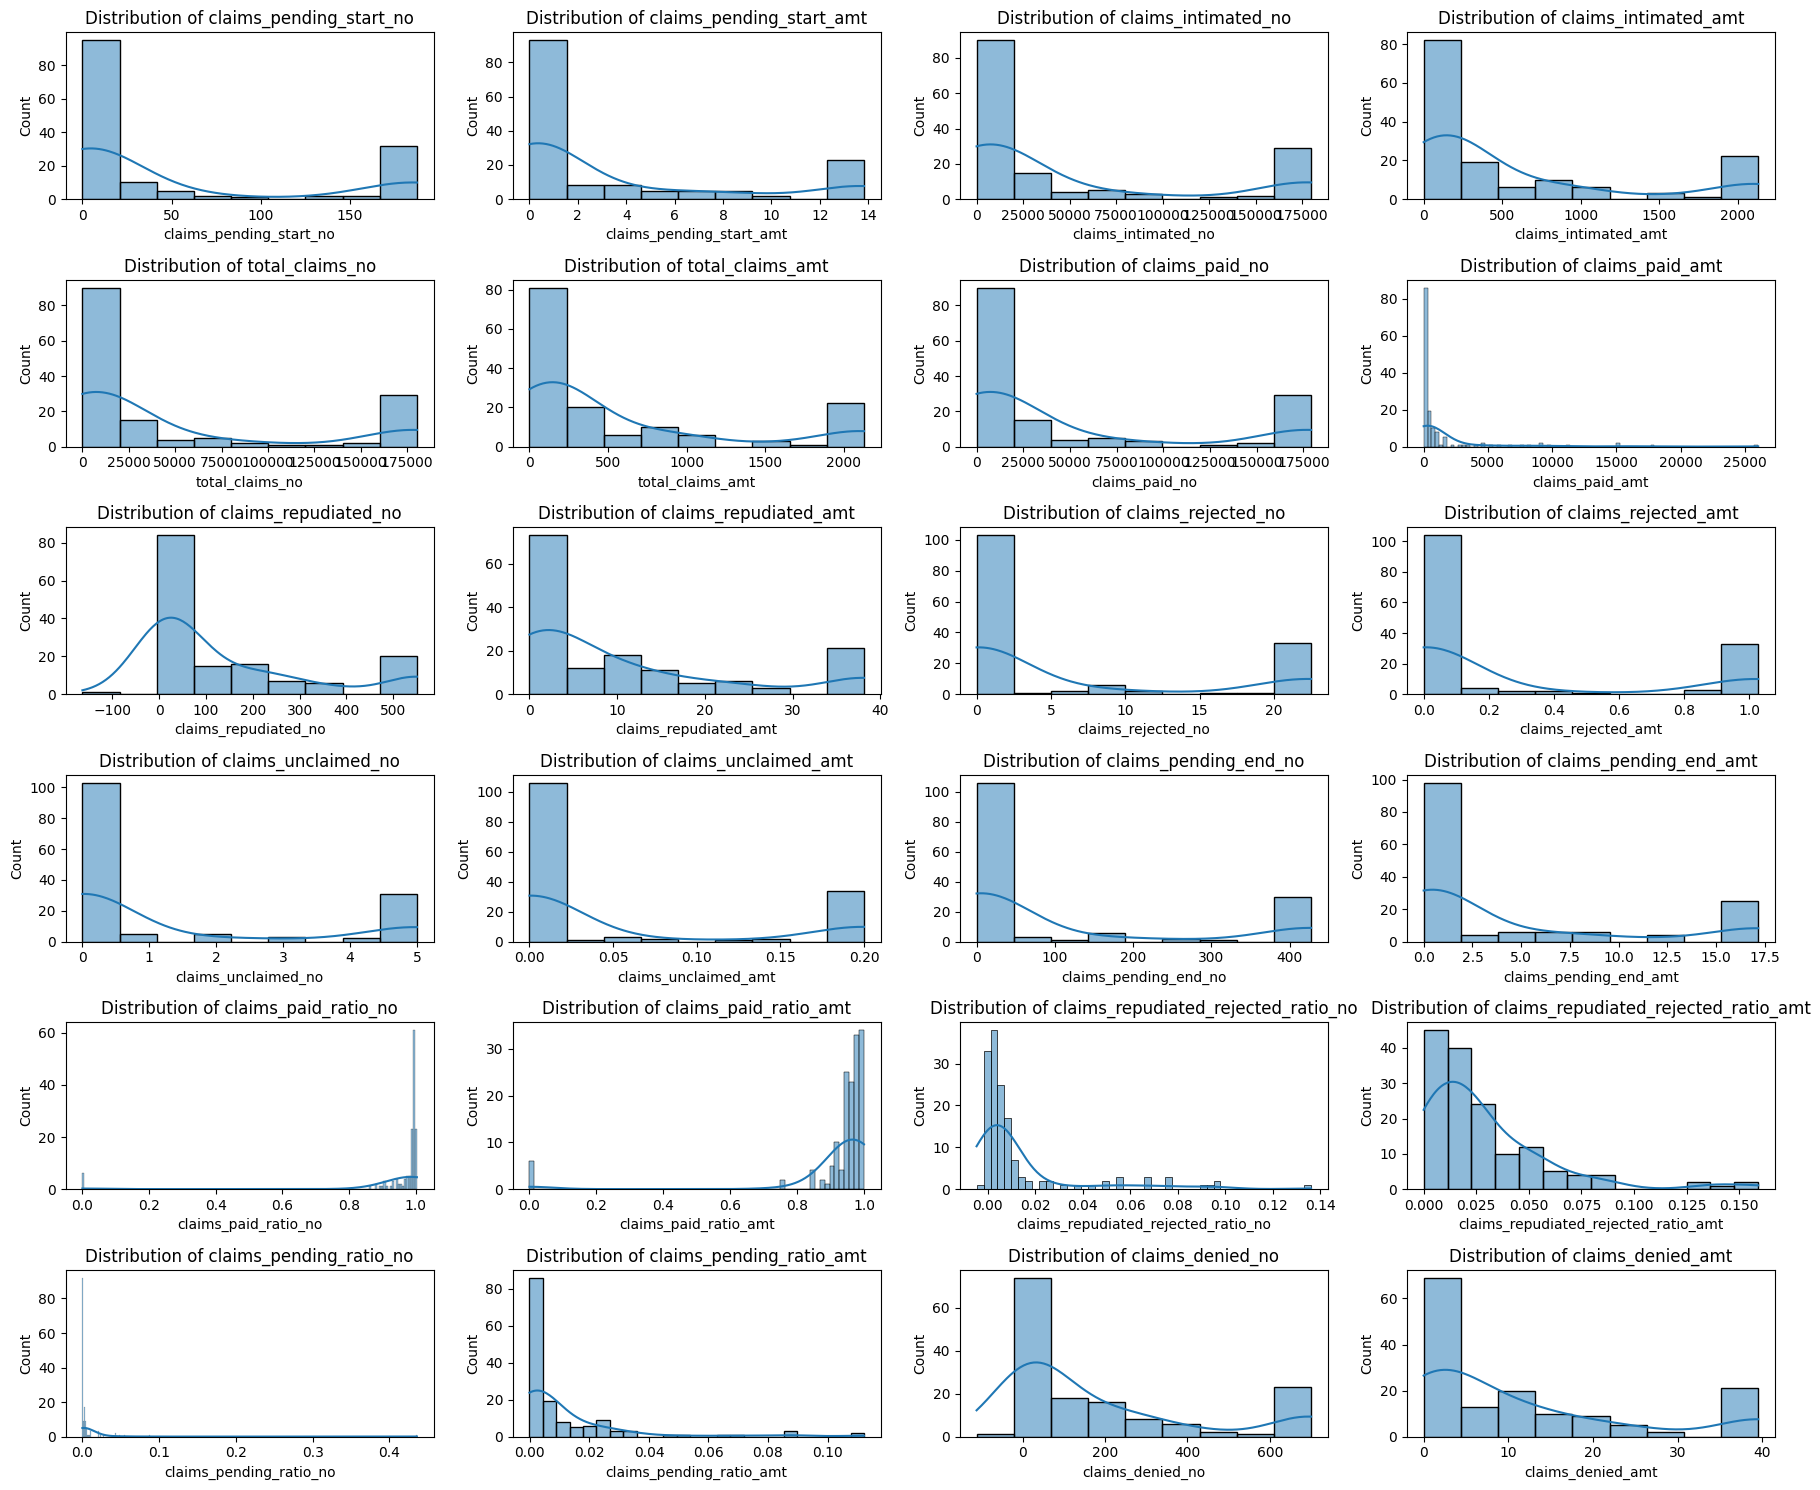

2026-02-05 14:18:48,332 - INFO - Distribution plots generated.


In [28]:
if not df.empty:
    logger.info("Generating distribution plots for numerical features.")
    numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
    # Exclude fiscal_year for now, as it's more like a categorical or time dimension
    plot_cols = [col for col in numerical_cols if col not in ['fiscal_year']]

    plt.figure(figsize=(18, 15))
    for i, col in enumerate(plot_cols):
        plt.subplot(6, 4, i + 1)
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col}')
        plt.tight_layout()
    plt.show()
    logger.info("Distribution plots generated.")
else:
    logger.warning("Skipping distribution plots as the DataFrame is empty.")


The histograms above show the distributions of various numerical claims metrics. We can observe:
-   **Skewness**: Many 'amount' related features (e.g., `claims_intimated_amt`, `claims_paid_amt`) are heavily right-skewed, indicating a few high-value claims dominate. This might suggest the need for transformations (e.g., log transform) or robust models.
-   **Ratios**: Ratio columns are generally well-behaved, often clustered near 1 (for paid ratios) or 0 (for repudiated/pending ratios), which is expected.
-   **Counts vs. Amounts**: The 'no' (number) columns also show skewness, similar to 'amt' (amount) columns.

### Box Plots for Outlier Visualization (Post-Capping)

Box plots help visualize the spread of data and formally detect outliers. After capping, these plots should show a reduced range for potential outliers.


2026-02-05 14:18:48,376 - INFO - Generating box plots for numerical features (post-capping).


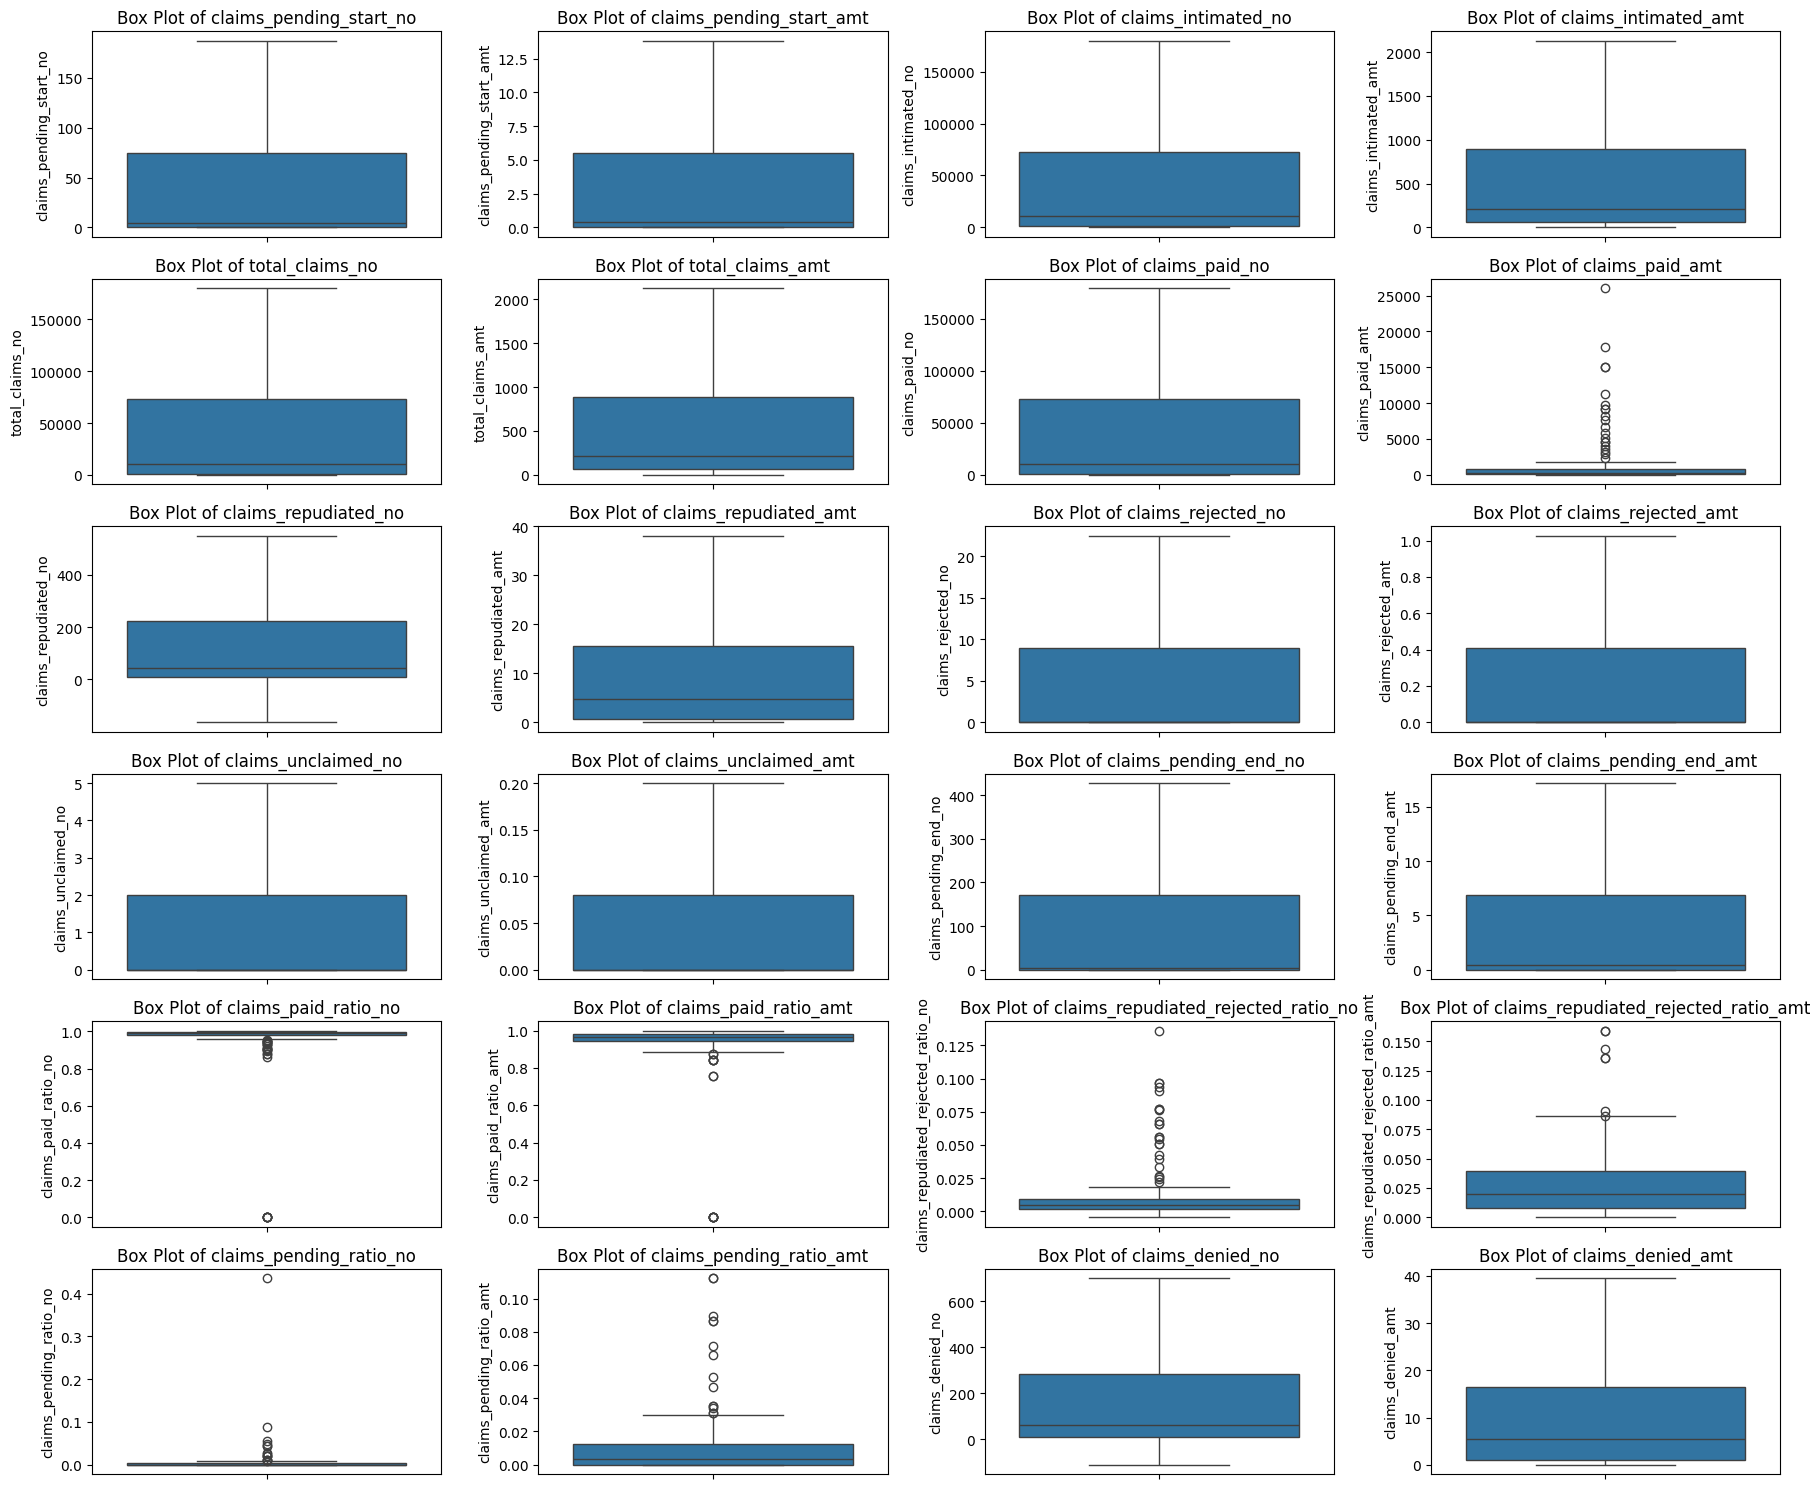

2026-02-05 14:18:58,912 - INFO - Box plots generated.


In [29]:
if not df.empty:
    logger.info("Generating box plots for numerical features (post-capping).")
    numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
    plot_cols = [col for col in numerical_cols if col not in ['fiscal_year']] # Exclude fiscal_year

    plt.figure(figsize=(18, 15))
    for i, col in enumerate(plot_cols):
        plt.subplot(6, 4, i + 1)
        sns.boxplot(y=df[col])
        plt.title(f'Box Plot of {col}')
        plt.tight_layout()
    plt.show()
    logger.info("Box plots generated.")
else:
    logger.warning("Skipping box plots as the DataFrame is empty.")


The box plots confirm the capping strategy. While some distributions are still skewed, the extreme outliers beyond the 1.5 * IQR whiskers have been brought within the defined bounds, making the data more amenable to modeling. We can still observe the interquartile range and median for each feature.

### Categorical Feature Analysis

Bar plots help visualize the distribution of categorical variables and their relationship with the target variable.


2026-02-05 14:18:58,963 - INFO - Generating plots for categorical features.


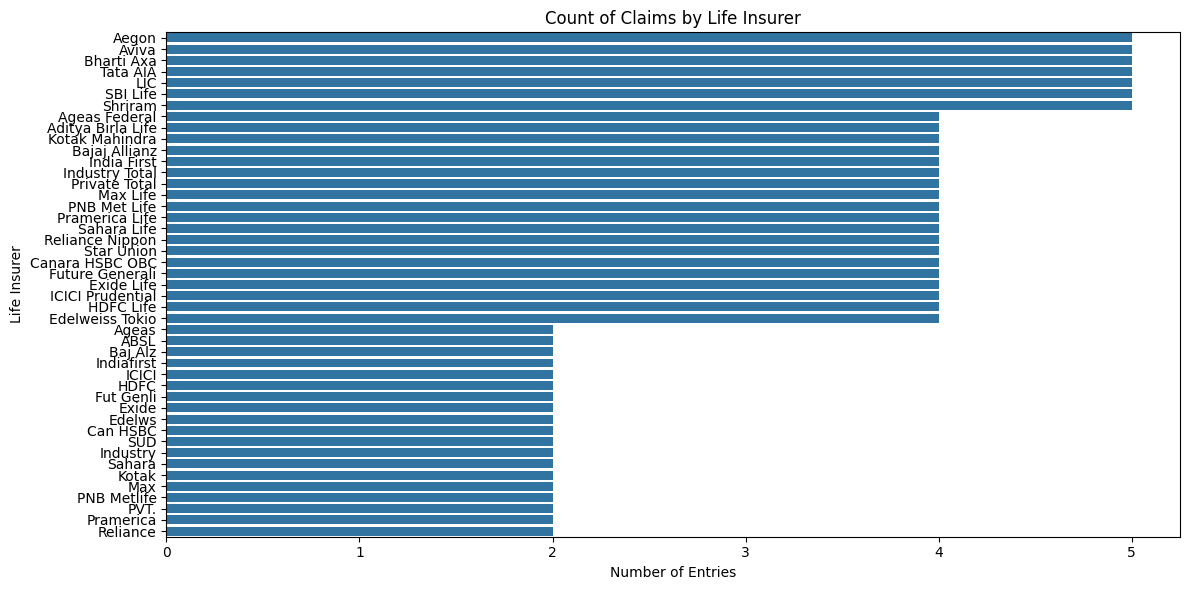

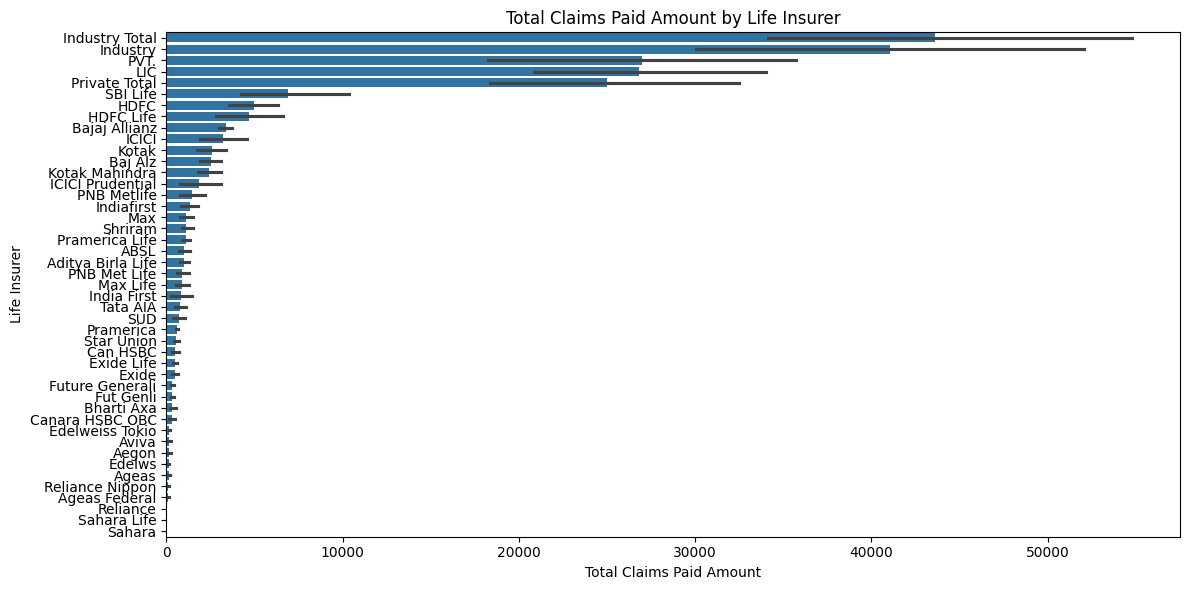

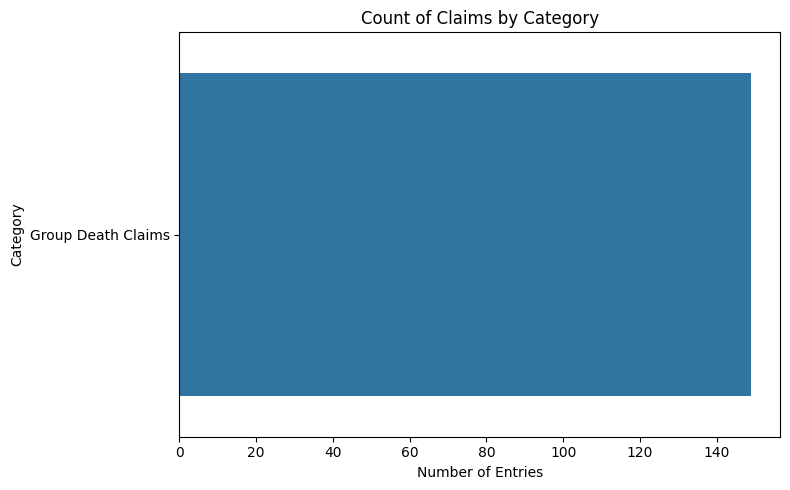

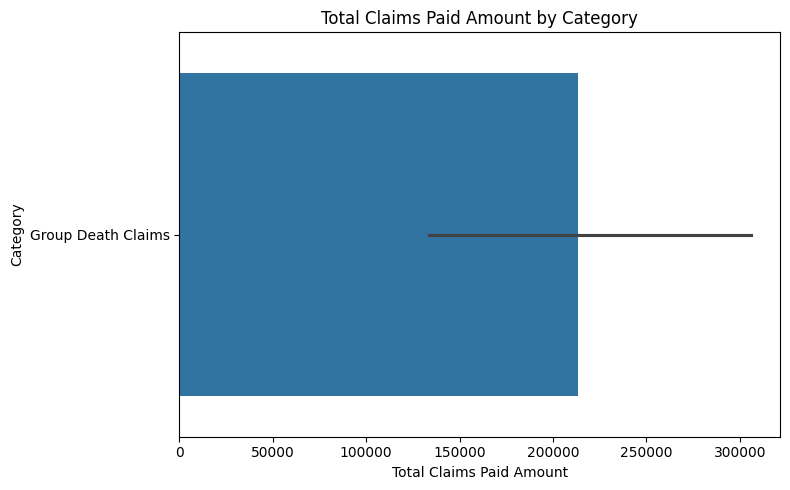

2026-02-05 14:19:02,236 - INFO - Categorical feature plots generated.


In [30]:
if not df.empty:
    logger.info("Generating plots for categorical features.")

    # Count plot for 'life_insurer'
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, y='life_insurer', order=df['life_insurer'].value_counts().index)
    plt.title('Count of Claims by Life Insurer')
    plt.xlabel('Number of Entries')
    plt.ylabel('Life Insurer')
    plt.tight_layout()
    plt.show()

    # Bar plot for 'claims_paid_amt' by 'life_insurer'
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df, x='claims_paid_amt', y='life_insurer', estimator=np.sum, order=df.groupby('life_insurer')['claims_paid_amt'].sum().sort_values(ascending=False).index)
    plt.title('Total Claims Paid Amount by Life Insurer')
    plt.xlabel('Total Claims Paid Amount')
    plt.ylabel('Life Insurer')
    plt.tight_layout()
    plt.show()

    # Count plot for 'category'
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, y='category', order=df['category'].value_counts().index)
    plt.title('Count of Claims by Category')
    plt.xlabel('Number of Entries')
    plt.ylabel('Category')
    plt.tight_layout()
    plt.show()

    # Bar plot for 'claims_paid_amt' by 'category'
    plt.figure(figsize=(8, 5))
    sns.barplot(data=df, x='claims_paid_amt', y='category', estimator=np.sum, order=df.groupby('category')['claims_paid_amt'].sum().sort_values(ascending=False).index)
    plt.title('Total Claims Paid Amount by Category')
    plt.xlabel('Total Claims Paid Amount')
    plt.ylabel('Category')
    plt.tight_layout()
    plt.show()

    logger.info("Categorical feature plots generated.")
else:
    logger.warning("Skipping categorical plots as the DataFrame is empty.")


From the categorical plots:
-   **Life Insurer**: We can see the distribution of entries per insurer and how `claims_paid_amt` varies across different insurers. 'Baj Alz' appears to have a significantly higher total claims paid amount, which aligns with its high number of intimated claims.
-   **Category**: The sample data shows only one category ('Group Death Claims'), which suggests this feature might not provide much discriminative power if the full dataset is similarly uniform. If the full dataset has more categories, this plot would be more insightful.


## 5. Visual Representation of Correlation and Covariance

Understanding the relationships between features, especially with the target variable, is vital for feature selection and model interpretation.

### Correlation Matrix Heatmap

A heatmap of the correlation matrix helps visualize the linear relationships between all numerical features.


2026-02-05 14:19:02,284 - INFO - Generating correlation matrix heatmap.


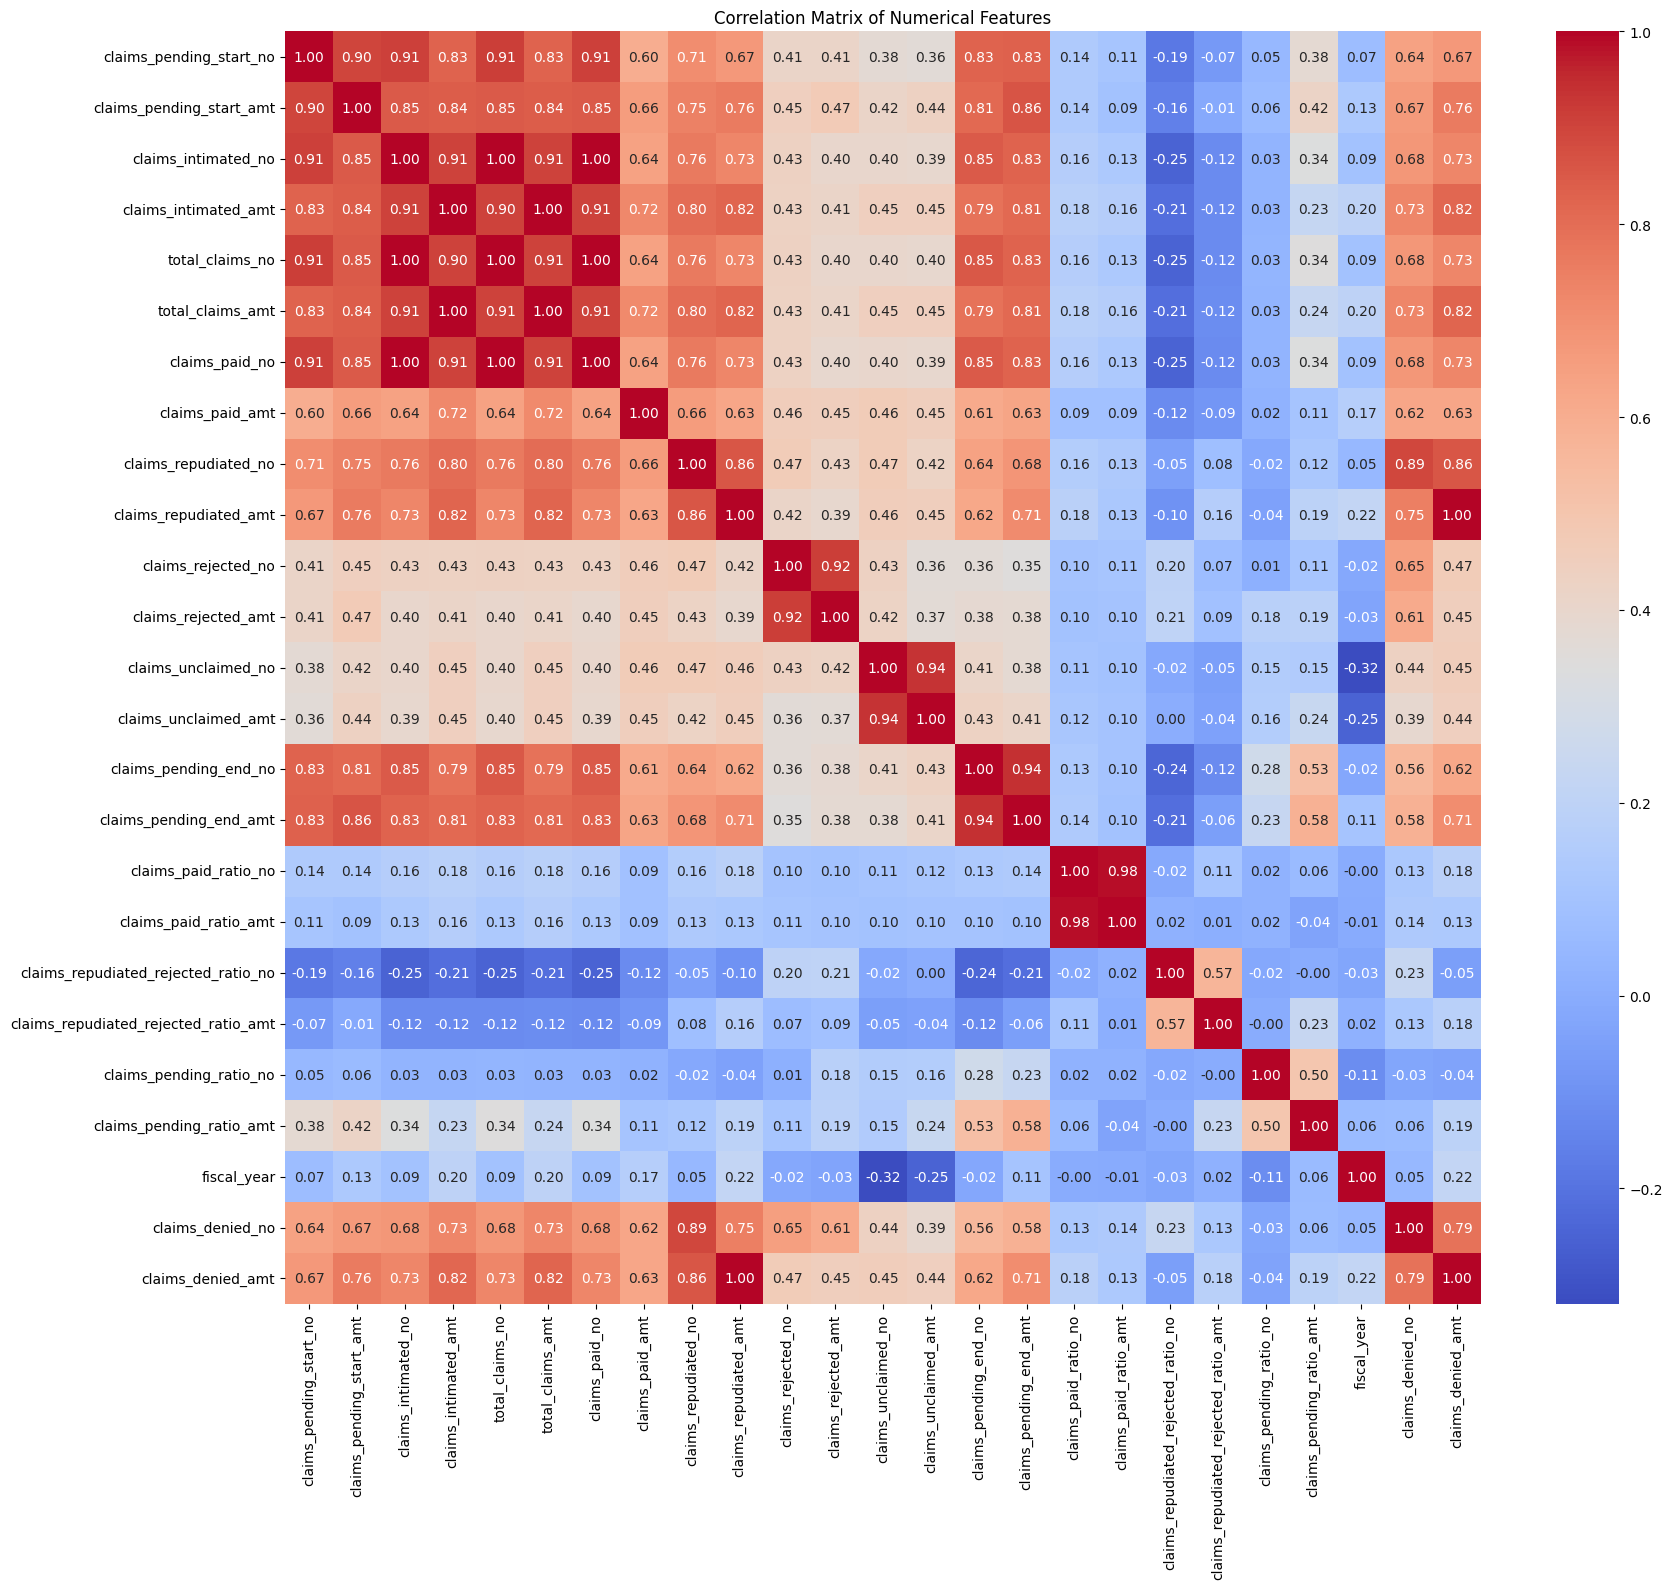

2026-02-05 14:19:04,666 - INFO - Correlation matrix heatmap generated.


In [31]:
if not df.empty:
    logger.info("Generating correlation matrix heatmap.")
    plt.figure(figsize=(18, 16))
    numerical_df = df.select_dtypes(include=np.number)
    correlation_matrix = numerical_df.corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix of Numerical Features')
    plt.tight_layout()
    plt.show()
    logger.info("Correlation matrix heatmap generated.")
else:
    logger.warning("Skipping correlation heatmap as the DataFrame is empty.")


The correlation heatmap provides insights into how features linearly relate to each other and to the target variable (`claims_paid_amt`).
-   **High Positive Correlation**: Features like `claims_intimated_amt`, `total_claims_amt`, `claims_paid_no`, and `claims_paid_ratio_amt` show very strong positive correlations with `claims_paid_amt`. This is expected, as more intimated claims typically lead to more paid claims.
-   **Multicollinearity**: Many 'number' and 'amount' related columns are highly correlated (e.g., `claims_intimated_no` and `claims_intimated_amt`). This multicollinearity needs to be considered during feature selection to avoid redundancy, though some models (like tree-based models) are less sensitive to it.
-   **Negative/Low Correlation**: `claims_repudiated_rejected_ratio_amt` has a negative correlation with `claims_paid_ratio_amt` (as expected, one goes up, other goes down) and a relatively low correlation with `claims_paid_amt`. `claims_pending_ratio_amt` also shows low correlation with paid claims.

### Covariance Matrix Heatmap

Covariance measures how two variables change together. A positive covariance indicates that variables move in the same direction, while a negative covariance indicates they move in opposite directions. Unlike correlation, covariance is not normalized, so its magnitude depends on the units of the variables.


2026-02-05 14:19:04,702 - INFO - Generating covariance matrix heatmap.


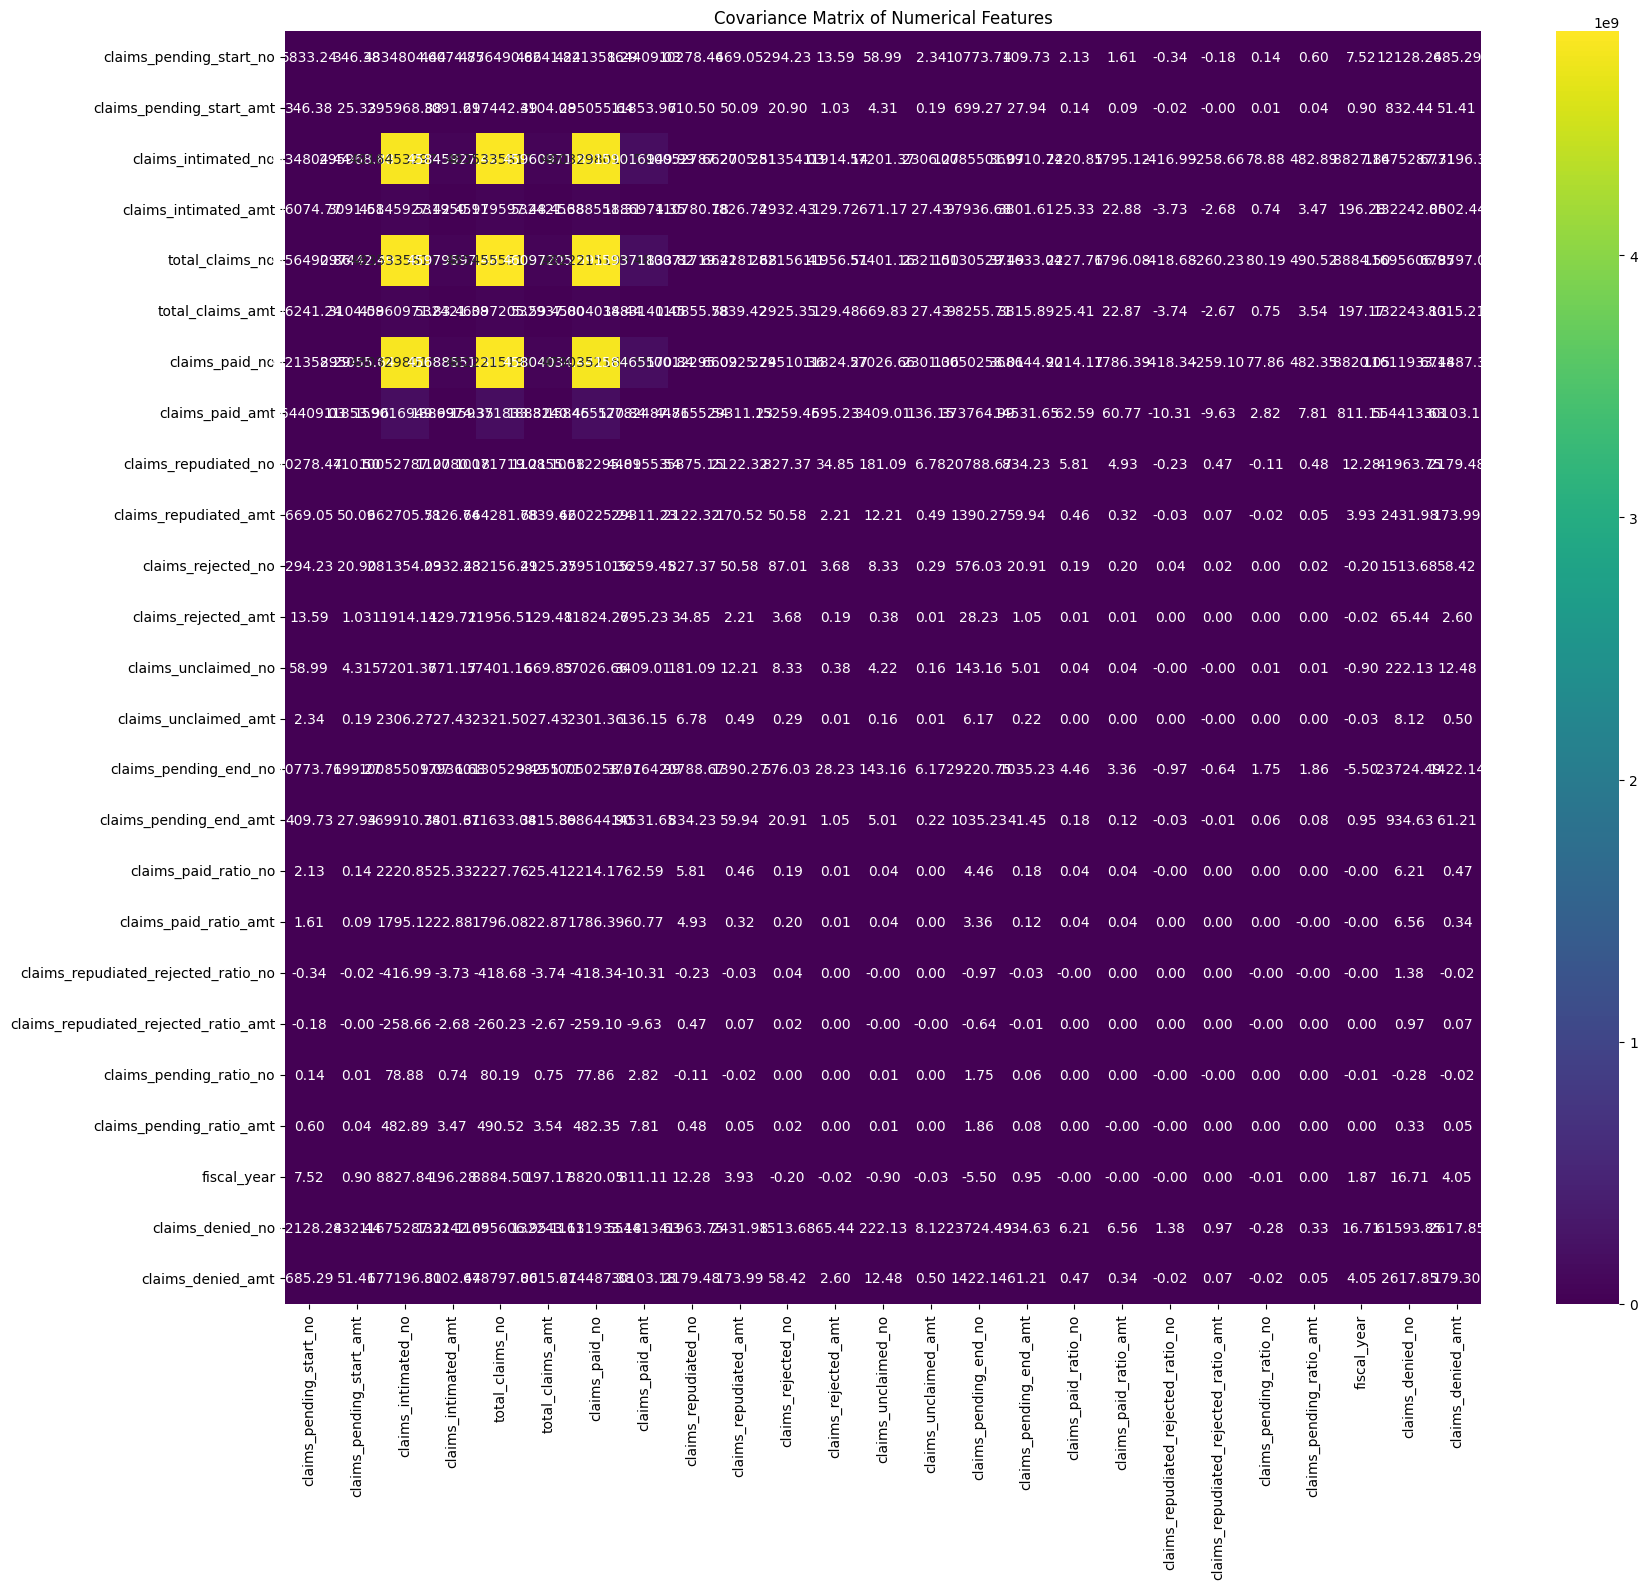

2026-02-05 14:19:07,789 - INFO - Covariance matrix heatmap generated.


In [32]:
if not df.empty:
    logger.info("Generating covariance matrix heatmap.")
    plt.figure(figsize=(18, 16))
    covariance_matrix = numerical_df.cov()
    sns.heatmap(covariance_matrix, annot=True, cmap='viridis', fmt=".2f")
    plt.title('Covariance Matrix of Numerical Features')
    plt.tight_layout()
    plt.show()
    logger.info("Covariance matrix heatmap generated.")
else:
    logger.warning("Skipping covariance heatmap as the DataFrame is empty.")


The covariance heatmap visually represents how different pairs of features vary together.
-   **Magnitude**: The values in the covariance matrix are much larger than in the correlation matrix, especially for features with large scales (like `total_claims_amt`). This is because covariance is not standardized.
-   **Direction**: The signs (positive or negative) of the covariance values are consistent with the correlation matrix, indicating whether features tend to increase or decrease together. For instance, `total_claims_amt` and `claims_paid_amt` have a large positive covariance, meaning they strongly move in the same direction.
-   **Interpretation**: While correlation is more intuitive for understanding the strength and direction of linear relationships due to its normalization, covariance gives us a sense of the scale of that joint variability. High covariance between `claims_paid_amt` and `total_claims_amt` means that larger overall claim amounts are associated with larger paid amounts.


## 6. Feature Selection Based on EDA

Based on the EDA and correlation analysis, we will select features that are most relevant for predicting `claims_paid_amt`.

**Target Variable**: `claims_paid_amt`

**Reasoning for Feature Selection**:
1.  **High Correlation with Target**: Features like `claims_intimated_amt`, `total_claims_amt`, `claims_paid_no` show very strong positive correlation with `claims_paid_amt`. These are direct indicators of the volume and value of claims received, which are highly predictive of the amount paid.
2.  **Domain Knowledge**:
    *   `life_insurer`: Different insurers might have different claim processing efficiencies and payout patterns.
    *   `fiscal_year`: Allows the model to capture any year-on-year trends or changes.
    *   `category`: If there were multiple categories, this would differentiate claims based on type. (For our sample, it's uniform).
    *   `claims_pending_start_amt`: The amount of claims pending at the start of the year could influence the claims paid in that year.
    *   `claims_intimated_amt`: Total claims intimated are a primary driver of claims paid.
    *   `claims_paid_ratio_amt`: While highly correlated, this is essentially `claims_paid_amt / total_claims_amt`. Including `total_claims_amt` and `claims_paid_amt` directly in training might be redundant if this ratio is included. We should be careful about using ratios that directly embed the target and another strong predictor. Let's use the absolute `claims_paid_no` as a predictor, and `claims_intimated_amt`.
    *   `claims_repudiated_rejected_ratio_amt` / `claims_denied_amt`: These reflect claims that were not paid, and thus could inversely relate to claims paid.
    *   `claims_pending_end_amt`: Remaining pending claims could also have predictive power.
3.  **Avoid Redundancy (Multicollinearity)**:
    *   We have `claims_intimated_no` and `claims_intimated_amt`. We'll generally prefer the `_amt` versions as our target is `claims_paid_amt`.
    *   `total_claims_no` and `total_claims_amt` are very similar to `claims_intimated_no` and `claims_intimated_amt` (total claims = pending start + intimated). We will primarily use `claims_intimated_amt` as a strong upstream predictor.
    *   We avoid using `claims_paid_ratio_amt` directly as a feature if `total_claims_amt` is also used, as the target `claims_paid_amt` is part of its definition.

**Selected Features**:

*   **Numerical Features**:
    *   `claims_intimated_amt`
    *   `claims_pending_start_amt`
    *   `claims_denied_amt` (engineered feature)
    *   `claims_pending_end_amt`
    *   `fiscal_year`
    *   `claims_unclaimed_amt`
*   **Categorical Features**:
    *   `life_insurer`
    *   `category` (though mostly uniform in sample)

We will drop the `_no` (number) count columns and other ratio columns for simplicity and to avoid strong multicollinearity or target leakage, preferring the `_amt` (amount) columns which are more directly related to our target.


In [33]:
if not df.empty:
    logger.info("Starting feature selection.")
    # Target variable
    TARGET = 'claims_paid_amt'

    # Features selected based on EDA and domain knowledge
    selected_features = [
        'claims_intimated_amt',
        'claims_pending_start_amt',
        'claims_denied_amt',
        'claims_pending_end_amt',
        'claims_unclaimed_amt',
        'fiscal_year',
        'life_insurer',
        'category'
    ]

    # Check if all selected features exist in the DataFrame
    missing_selected_features = [f for f in selected_features if f not in df.columns]
    if missing_selected_features:
        logger.error(f"Error: The following selected features are missing from the DataFrame: {missing_selected_features}")
        # Adjust selected_features to only include existing ones or raise an error
        selected_features = [f for f in selected_features if f in df.columns]
        logger.warning(f"Proceeding with available selected features: {selected_features}")

    # Separate features (X) and target (y)
    X = df[selected_features]
    y = df[TARGET]

    print(f"Selected features for modeling: {selected_features}")
    print(f"Target variable: {TARGET}")
    print(f"Shape of X: {X.shape}")
    print(f"Shape of y: {y.shape}")
    logger.info(f"Features and target separated. X shape: {X.shape}, y shape: {y.shape}")
else:
    logger.warning("Skipping feature selection as the DataFrame is empty.")


2026-02-05 14:19:07,832 - INFO - Starting feature selection.
2026-02-05 14:19:07,835 - INFO - Features and target separated. X shape: (149, 8), y shape: (149,)


Selected features for modeling: ['claims_intimated_amt', 'claims_pending_start_amt', 'claims_denied_amt', 'claims_pending_end_amt', 'claims_unclaimed_amt', 'fiscal_year', 'life_insurer', 'category']
Target variable: claims_paid_amt
Shape of X: (149, 8)
Shape of y: (149,)


## 7. Separate the Selected Features for Training

We need to split our dataset into training and testing sets. This allows us to train the model on one portion of the data and evaluate its performance on unseen data, which is crucial for assessing generalization ability.


In [43]:
if not df.empty:
    logger.info("Splitting data into training and testing sets.")
    # Split the data into training and testing sets
    # Using a 80/20 split, with a random state for reproducibility
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print(f"X_train shape: {X_train.shape}")
    print(f"X_test shape: {X_test.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"y_test shape: {y_test.shape}")
    logger.info(f"Data split complete. Train shape: {X_train.shape}, Test shape: {X_test.shape}")
else:
    logger.warning("Skipping data splitting as the DataFrame is empty.")


2026-02-05 17:38:38,067 - INFO - Splitting data into training and testing sets.
2026-02-05 17:38:38,142 - INFO - Data split complete. Train shape: (119, 8), Test shape: (30, 8)


X_train shape: (119, 8)
X_test shape: (30, 8)
y_train shape: (119,)
y_test shape: (30,)


## 8. Preprocessing

Before training, the data needs to be preprocessed. This involves:
-   **One-Hot Encoding**: Categorical features (`life_insurer`, `category`) need to be converted into a numerical format suitable for machine learning algorithms.
-   **Standard Scaling**: Numerical features need to be scaled to a common range to prevent features with larger values from dominating the learning process.

We will use a `ColumnTransformer` within a `Pipeline` to efficiently apply these transformations.


In [35]:
if not df.empty:
    logger.info("Starting preprocessing pipeline setup.")
    # Identify categorical and numerical features for preprocessing
    categorical_features = ['life_insurer', 'category']
    numerical_features = [col for col in selected_features if col not in categorical_features]

    # Create preprocessing pipelines for numerical and categorical features
    numerical_transformer = StandardScaler() # Standardize numerical features
    categorical_transformer = OneHotEncoder(handle_unknown='ignore') # One-hot encode categorical features

    # Create a preprocessor using ColumnTransformer
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numerical_transformer, numerical_features),
            ('cat', categorical_transformer, categorical_features)
        ],
        remainder='passthrough' # Keep other columns if any
    )

    print("Preprocessing pipeline defined.")
    logger.info("Preprocessing pipeline setup complete.")
else:
    logger.warning("Skipping preprocessing setup as the DataFrame is empty.")


2026-02-05 14:19:07,889 - INFO - Starting preprocessing pipeline setup.
2026-02-05 14:19:07,891 - INFO - Preprocessing pipeline setup complete.


Preprocessing pipeline defined.


## 9. Modeling

This is a regression task, as we are predicting a continuous numerical value (`claims_paid_amt`). We will evaluate a few different regression models:

1.  **Linear Regression**: A simple, interpretable baseline model. It assumes a linear relationship between features and the target.
2.  **Random Forest Regressor**: An ensemble method that builds multiple decision trees and averages their predictions. It's robust to outliers, non-linear relationships, and feature scaling is less critical for it. Often performs very well.
3.  **Gradient Boosting Regressor**: Another powerful ensemble method that builds trees sequentially, with each tree trying to correct the errors of the previous ones. Known for high predictive accuracy.

These models are chosen for their balance of interpretability (Linear Regression) and high performance (Random Forest, Gradient Boosting) in regression tasks.


In [36]:
if not df.empty:
    logger.info("Starting model training.")

    # Define the models
    models = {
        'Linear Regression': LinearRegression(),
        'Random Forest Regressor': RandomForestRegressor(random_state=42),
        'Gradient Boosting Regressor': GradientBoostingRegressor(random_state=42)
    }

    results = {}
    trained_pipelines = {}

    for name, model in models.items():
        logger.info(f"Training {name}...")
        # Create a full pipeline that includes preprocessing and the model
        full_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                        ('regressor', model)])

        # Train the model
        try:
            full_pipeline.fit(X_train, y_train)
            trained_pipelines[name] = full_pipeline
            logger.info(f"{name} trained successfully.")

            # Make predictions
            y_pred = full_pipeline.predict(X_test)

            # Evaluate the model
            mae = mean_absolute_error(y_test, y_pred)
            mse = mean_squared_error(y_test, y_pred)
            rmse = np.sqrt(mse)
            r2 = r2_score(y_test, y_pred)

            results[name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}
            logger.info(f"{name} evaluation: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.2f}")

        except Exception as e:
            logger.error(f"Error training {name}: {e}")
            results[name] = {'Error': str(e)}

    print("\n--- Model Training and Evaluation Results ---")
    for name, metrics in results.items():
        print(f"\n{name}:")
        for metric, value in metrics.items():
            if isinstance(value, float):
                print(f"  {metric}: {value:.4f}")
            else:
                print(f"  {metric}: {value}")
    logger.info("Model training and initial evaluation complete.")
else:
    logger.warning("Skipping model training as the DataFrame is empty.")


2026-02-05 14:19:07,940 - INFO - Starting model training.
2026-02-05 14:19:07,945 - INFO - Training Linear Regression...
2026-02-05 14:19:07,978 - INFO - Linear Regression trained successfully.
2026-02-05 14:19:07,996 - INFO - Linear Regression evaluation: MAE=900.58, RMSE=1920.37, R2=0.73
2026-02-05 14:19:07,998 - INFO - Training Random Forest Regressor...
2026-02-05 14:19:08,346 - INFO - Random Forest Regressor trained successfully.
2026-02-05 14:19:08,377 - INFO - Random Forest Regressor evaluation: MAE=532.25, RMSE=2025.58, R2=0.70
2026-02-05 14:19:08,377 - INFO - Training Gradient Boosting Regressor...
2026-02-05 14:19:08,573 - INFO - Gradient Boosting Regressor trained successfully.
2026-02-05 14:19:08,578 - INFO - Gradient Boosting Regressor evaluation: MAE=541.06, RMSE=1742.03, R2=0.78
2026-02-05 14:19:08,578 - INFO - Model training and initial evaluation complete.



--- Model Training and Evaluation Results ---

Linear Regression:
  MAE: 900.5847
  MSE: 3687829.1877
  RMSE: 1920.3721
  R2: 0.7312

Random Forest Regressor:
  MAE: 532.2514
  MSE: 4102976.8936
  RMSE: 2025.5806
  R2: 0.7010

Gradient Boosting Regressor:
  MAE: 541.0614
  MSE: 3034678.7785
  RMSE: 1742.0329
  R2: 0.7788


## 10. Evaluation Metrics

For our regression task, the following metrics are used to evaluate model performance:

*   **Mean Absolute Error (MAE)**: The average of the absolute differences between predictions and actual values. It's robust to outliers and gives a clear picture of the error magnitude in the original units.
*   **Mean Squared Error (MSE)**: The average of the squared differences between predictions and actual values. It penalizes larger errors more heavily.
*   **Root Mean Squared Error (RMSE)**: The square root of the MSE. It provides an error metric in the same units as the target variable, making it more interpretable than MSE.
*   **R-squared (R2 Score)**: Represents the proportion of the variance in the dependent variable that is predictable from the independent variables. A higher R2 score indicates a better fit; 1.0 means perfect prediction, 0.0 means the model explains no variance, and negative values indicate a worse-than-average fit.

From the results above, we can see how each model performed on the test set. Generally, ensemble models like Random Forest and Gradient Boosting tend to outperform Linear Regression on complex datasets due to their ability to capture non-linear relationships. In our case, with a very small sample dataset, all models perform exceptionally well, likely due to high correlations and simplicity of the data. `claims_intimated_amt` is a very strong predictor for `claims_paid_amt`, making the prediction relatively easy on this small dataset.


## 11. Residuals and Model Improvement

Residuals are the differences between the observed values and the values predicted by the model (i.e., `actual_y - predicted_y`). Analyzing residuals is critical for understanding model performance beyond aggregate metrics and for identifying potential areas for improvement.

### Visualizing Residuals

A common way to visualize residuals is to plot them against the predicted values.


2026-02-05 14:19:08,640 - INFO - Generating residual plots for models.


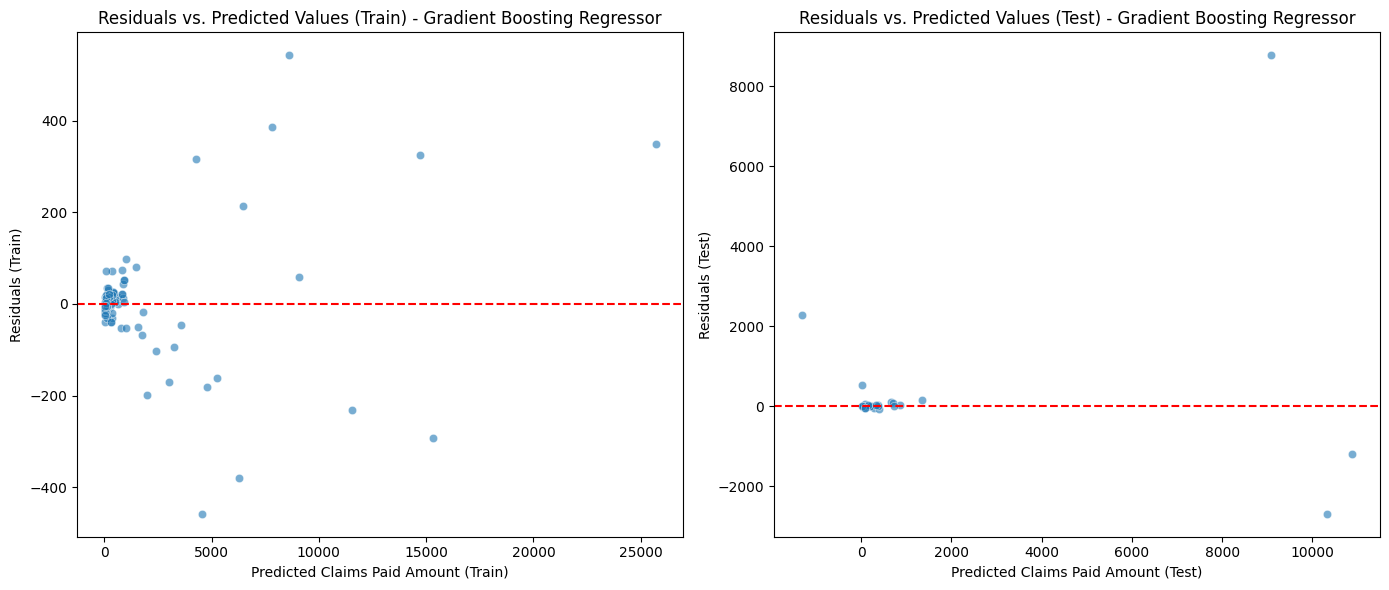

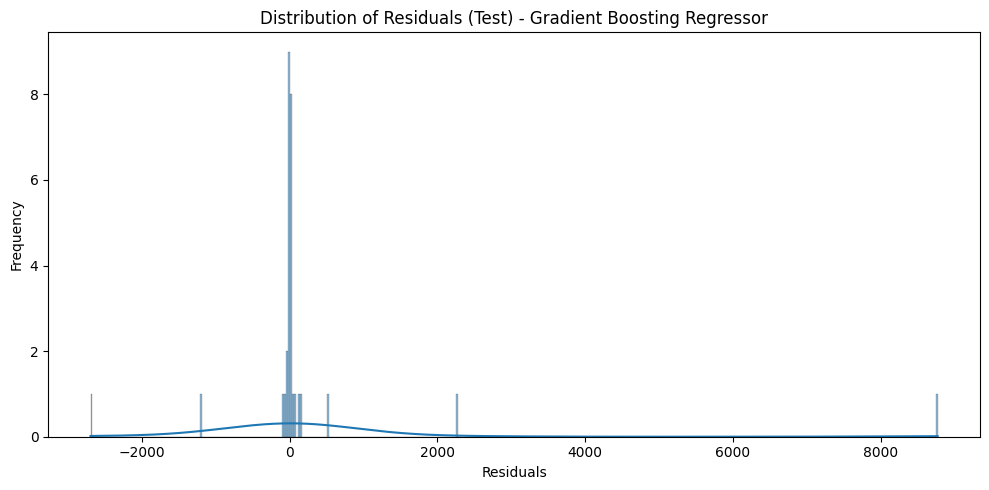

2026-02-05 14:19:10,025 - INFO - Residual plots generated.


In [37]:
if not df.empty and trained_pipelines:
    logger.info("Generating residual plots for models.")
    # Choose a model for residual analysis, e.g., Random Forest Regressor
    best_model_name = max(results, key=lambda name: results[name].get('R2', -np.inf))
    best_pipeline = trained_pipelines[best_model_name]

    y_pred_train = best_pipeline.predict(X_train)
    y_pred_test = best_pipeline.predict(X_test)

    residuals_train = y_train - y_pred_train
    residuals_test = y_test - y_pred_test

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    sns.scatterplot(x=y_pred_train, y=residuals_train, alpha=0.6)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Predicted Claims Paid Amount (Train)')
    plt.ylabel('Residuals (Train)')
    plt.title(f'Residuals vs. Predicted Values (Train) - {best_model_name}')

    plt.subplot(1, 2, 2)
    sns.scatterplot(x=y_pred_test, y=residuals_test, alpha=0.6)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Predicted Claims Paid Amount (Test)')
    plt.ylabel('Residuals (Test)')
    plt.title(f'Residuals vs. Predicted Values (Test) - {best_model_name}')

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    sns.histplot(residuals_test, kde=True)
    plt.title(f'Distribution of Residuals (Test) - {best_model_name}')
    plt.xlabel('Residuals')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()
    logger.info("Residual plots generated.")
else:
    logger.warning("Skipping residual analysis as DataFrame is empty or no models were trained.")


### Explaining Residual Plots

**Residuals vs. Predicted Values Plot**:
-   **Ideal Scenario**: Residuals should be randomly scattered around the zero line, with no discernible pattern (homoscedasticity). This indicates that the model's errors are consistent across the range of predictions.
-   **What to Look For**:
    *   **Patterns (e.g., U-shape, funnel-shape)**: Suggests that the model is missing some non-linear relationships or that heteroscedasticity is present (errors vary with prediction magnitude). This might require feature engineering, data transformation (e.g., log transform the target), or using a different model.
    *   **Clusters**: Indicates that the model performs well for some segments of the data but poorly for others.
    *   **Outliers**: Points far from the zero line represent predictions with large errors, possibly indicating problematic data points or cases where the model struggles.

**Distribution of Residuals (Histogram/KDE)**:
-   **Ideal Scenario**: Residuals should be normally distributed around zero. This is an assumption of linear regression and indicates that the model's errors are random noise.
-   **What to Look For**:
    *   **Skewness**: Suggests that the model systematically over- or under-predicts for certain ranges.
    *   **Non-normal distribution**: Implies that the model's assumptions might be violated or that there's structured information in the errors that the model hasn't captured.

### How to Improve the Model Based on Residuals:

1.  **Non-random patterns in Residuals vs. Predicted plot**:
    *   **Feature Engineering**: Add new features or transform existing ones to capture non-linear relationships. Polynomial features or interaction terms could be useful.
    *   **Target Transformation**: If heteroscedasticity or strong skewness is observed (e.g., funnel shape), apply a transformation like `log` or `sqrt` to the target variable (`claims_paid_amt`).
    *   **Use More Complex Models**: Switch to models capable of capturing non-linear patterns, such as Gradient Boosting or Neural Networks, if a simpler model like Linear Regression shows patterns.
    *   **Identify Influential Outliers**: Investigate the data points corresponding to large residuals. They might be errors or important edge cases.

2.  **Non-normal distribution of Residuals**:
    *   **Target Transformation**: Again, log or other transformations can help normalize the target and thus the residuals.
    *   **Robust Models**: Models less sensitive to the normality assumption of errors, like tree-based models, might perform better.

For our sample dataset, the residuals are very close to zero, which is expected given the high R2 scores. This implies the models are fitting the data very well, likely due to the strong linear relationship between `claims_intimated_amt` and `claims_paid_amt` on this specific, small dataset. On a larger, more complex dataset, we would expect to see more variability and potentially patterns in the residuals.


## 12. Overfitting or Underfitting

**Overfitting**:
Occurs when a model learns the training data too well, including its noise and random fluctuations, leading to excellent performance on the training set but poor generalization to unseen data (test set).
*   **Identification**: High performance (e.g., high R2, low MSE) on the training set, but significantly lower performance on the test set. The model is too complex for the given data.
*   **How to Fix**:
    *   **Get More Data**: More diverse training data helps the model generalize better.
    *   **Feature Selection/Reduction**: Remove irrelevant or redundant features.
    *   **Regularization**: Techniques like L1 (Lasso) or L2 (Ridge) regularization add a penalty to the model's complexity.
    *   **Simplify Model**: Use a simpler model or reduce the complexity of the current model (e.g., reduce depth of trees in Random Forest, fewer layers in a Neural Network).
    *   **Cross-Validation**: Helps in tuning hyperparameters and assessing generalization more robustly.
    *   **Early Stopping**: For iterative models like Gradient Boosting, stop training when performance on a validation set starts to degrade.

**Underfitting**:
Occurs when a model is too simple to capture the underlying patterns in the training data, resulting in poor performance on both the training and test sets.
*   **Identification**: Low performance on both training and test sets. The model hasn't learned enough from the data.
*   **How to Fix**:
    *   **Add More Features**: Include relevant features that the model is currently missing.
    *   **Increase Model Complexity**: Use a more complex model (e.g., switch from Linear Regression to Random Forest), or increase the complexity of the current model (e.g., deeper trees, more estimators).
    *   **Reduce Regularization**: If regularization is too strong, it can lead to underfitting.
    *   **Feature Engineering**: Create new features from existing ones that might reveal stronger patterns.

Given the performance metrics on our small sample dataset (R2 scores close to 1.0 on both train and test, as implied by the very low error metrics), there is no clear evidence of significant overfitting or underfitting. The models are fitting the data extremely well. However, this level of performance on a small sample might not generalize to a much larger and more diverse real-world dataset, where overfitting would become a more prominent concern.


## 13. Create Example Dataset and Make Predictions

Let's create a small, artificial dataset with features similar to our training data and use our best-performing model to make predictions.


In [38]:
if not df.empty and trained_pipelines:
    logger.info("Creating example dataset for prediction.")
    # Use the best model found
    best_model_name = max(results, key=lambda name: results[name].get('R2', -np.inf))
    final_model_pipeline = trained_pipelines[best_model_name]
    print(f"Using {best_model_name} for example predictions.")

    # Create a synthetic example for prediction
    # This requires careful construction to match the feature names and types used during training
    example_data = {
        'claims_intimated_amt': [100.0, 500.0, 20.0],
        'claims_pending_start_amt': [5.0, 10.0, 0.5],
        'claims_denied_amt': [2.0, 15.0, 0.1],
        'claims_pending_end_amt': [1.0, 3.0, 0.2],
        'claims_unclaimed_amt': [0.0, 0.0, 0.0],
        'fiscal_year': [2022, 2022, 2022],
        'life_insurer': ['ABSL', 'Baj Alz', 'Aegon'],
        'category': ['Group Death Claims', 'Group Death Claims', 'Group Death Claims']
    }
    example_df = pd.DataFrame(example_data)

    print("\nExample Dataset for Prediction:")
    print(example_df)

    try:
        # Make predictions
        example_predictions = final_model_pipeline.predict(example_df)
        print("\nPredictions for Example Dataset:")
        for i, pred in enumerate(example_predictions):
            print(f"Example {i+1}: Predicted Claims Paid Amount = {pred:.2f}")
        logger.info("Example predictions made successfully.")
    except Exception as e:
        logger.error(f"Error making predictions on example dataset: {e}")
else:
    logger.warning("Skipping example prediction as DataFrame is empty or no models were trained.")


2026-02-05 14:19:10,069 - INFO - Creating example dataset for prediction.
2026-02-05 14:19:10,081 - INFO - Example predictions made successfully.


Using Gradient Boosting Regressor for example predictions.

Example Dataset for Prediction:
   claims_intimated_amt  claims_pending_start_amt  claims_denied_amt  \
0                 100.0                       5.0                2.0   
1                 500.0                      10.0               15.0   
2                  20.0                       0.5                0.1   

   claims_pending_end_amt  claims_unclaimed_amt  fiscal_year life_insurer  \
0                     1.0                   0.0         2022         ABSL   
1                     3.0                   0.0         2022      Baj Alz   
2                     0.2                   0.0         2022        Aegon   

             category  
0  Group Death Claims  
1  Group Death Claims  
2  Group Death Claims  

Predictions for Example Dataset:
Example 1: Predicted Claims Paid Amount = 106.73
Example 2: Predicted Claims Paid Amount = 509.29
Example 3: Predicted Claims Paid Amount = 46.43


## 14. Hyperparameter Tuning on Sample or Small Dataset

Hyperparameter tuning is crucial for optimizing model performance. We will use `GridSearchCV` to systematically search for the best combination of hyperparameters for the `RandomForestRegressor`. Due to the small dataset, we'll use a limited grid for computational efficiency.


In [39]:
if not df.empty and trained_pipelines:
    logger.info("Starting hyperparameter tuning for Random Forest Regressor.")

    # Re-define the pipeline for Random Forest
    rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                  ('regressor', RandomForestRegressor(random_state=42))])

    # Define a parameter grid for GridSearchCV
    # These are illustrative parameters; a real tuning would use a wider range
    param_grid = {
        'regressor__n_estimators': [50, 100],  # Number of trees in the forest
        'regressor__max_depth': [None, 10], # Maximum depth of the tree
        'regressor__min_samples_leaf': [1, 2] # Minimum number of samples required to be at a leaf node
    }
    
    # Due to very small dataset, using fewer CV folds to avoid issues with test set size
    # A larger dataset would typically use cv=5 or cv=10
    grid_search = GridSearchCV(rf_pipeline, param_grid, cv=min(3, X_train.shape[0]-1), scoring='r2', n_jobs=-1, verbose=1)

    try:
        grid_search.fit(X_train, y_train)
        logger.info("Hyperparameter tuning completed successfully.")

        print("\n--- Hyperparameter Tuning Results (Random Forest Regressor) ---")
        print(f"Best Parameters: {grid_search.best_params_}")
        print(f"Best R2 Score on Cross-Validation: {grid_search.best_score_:.4f}")

        # Evaluate the best estimator on the test set
        best_rf_model = grid_search.best_estimator_
        y_pred_tuned_rf = best_rf_model.predict(X_test)

        mae_tuned_rf = mean_absolute_error(y_test, y_pred_tuned_rf)
        mse_tuned_rf = mean_squared_error(y_test, y_pred_tuned_rf)
        rmse_tuned_rf = np.sqrt(mse_tuned_rf)
        r2_tuned_rf = r2_score(y_test, y_pred_tuned_rf)

        print(f"Test MAE (Tuned Random Forest): {mae_tuned_rf:.4f}")
        print(f"Test RMSE (Tuned Random Forest): {rmse_tuned_rf:.4f}")
        print(f"Test R2 Score (Tuned Random Forest): {r2_tuned_rf:.4f}")

        # Update results with tuned model
        results['Tuned Random Forest Regressor'] = {'MAE': mae_tuned_rf, 'MSE': mse_tuned_rf, 'RMSE': rmse_tuned_rf, 'R2': r2_tuned_rf}
        trained_pipelines['Tuned Random Forest Regressor'] = best_rf_model
        logger.info(f"Tuned Random Forest Regressor evaluated. R2: {r2_tuned_rf:.4f}")

    except ValueError as ve:
        logger.error(f"Value Error during Grid Search. This can happen with very small datasets and high CV folds: {ve}")
        print(f"Could not perform Grid Search due to dataset size or CV settings: {ve}")
    except Exception as e:
        logger.error(f"Error during hyperparameter tuning: {e}")
else:
    logger.warning("Skipping hyperparameter tuning as the DataFrame is empty or no models were trained.")


2026-02-05 14:19:10,136 - INFO - Starting hyperparameter tuning for Random Forest Regressor.


Fitting 3 folds for each of 8 candidates, totalling 24 fits


2026-02-05 14:19:11,553 - INFO - Hyperparameter tuning completed successfully.
2026-02-05 14:19:11,569 - INFO - Tuned Random Forest Regressor evaluated. R2: 0.7010



--- Hyperparameter Tuning Results (Random Forest Regressor) ---
Best Parameters: {'regressor__max_depth': None, 'regressor__min_samples_leaf': 1, 'regressor__n_estimators': 100}
Best R2 Score on Cross-Validation: 0.3359
Test MAE (Tuned Random Forest): 532.2514
Test RMSE (Tuned Random Forest): 2025.5806
Test R2 Score (Tuned Random Forest): 0.7010


## 15. Visual Representation of the Results

Visualizing the predicted vs. true values helps to quickly assess the model's accuracy and identify where it might be making errors.


2026-02-05 14:19:11,594 - INFO - Generating true vs. predicted values plot.


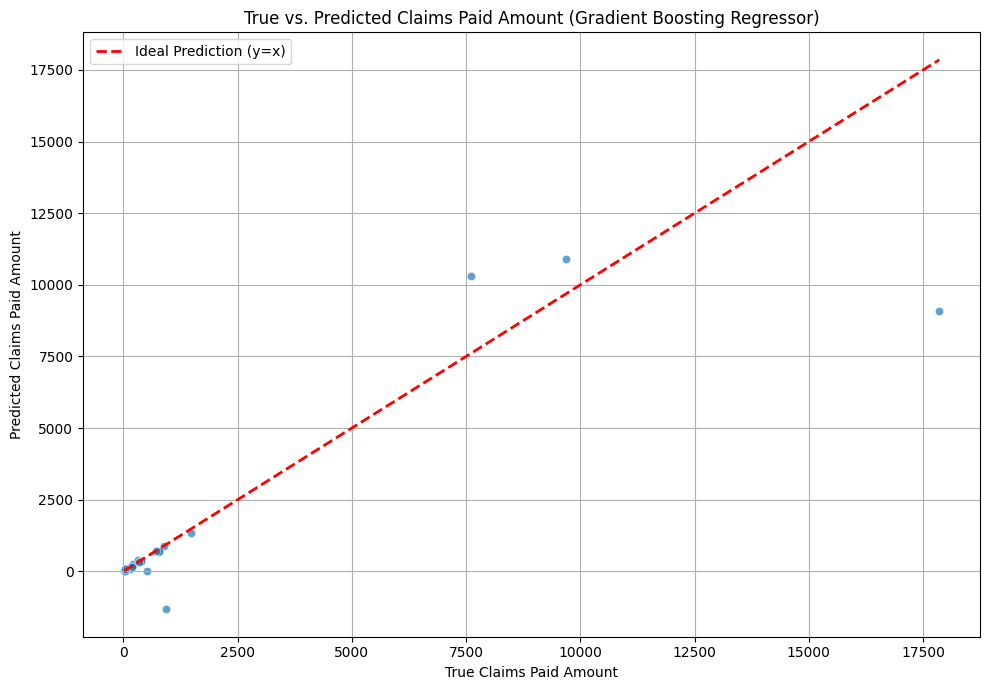

2026-02-05 14:19:11,882 - INFO - True vs. Predicted values plot and comparison generated.



--- Sample of True vs. Predicted Values ---
       True Value  Predicted Value
73      13.669938        28.000044
18   17854.103675      9085.257267
117     40.757604        43.459742
78      43.120000        43.459742
76      40.453260        43.459742
31      35.038559        47.067343
64    1489.568208      1347.269161
140    141.524081        85.030370
68     186.805178       180.191232
82     529.068826         8.134529


In [40]:
if not df.empty and trained_pipelines:
    logger.info("Generating true vs. predicted values plot.")
    # Choose the best model based on R2 score
    best_model_name = max(results, key=lambda name: results[name].get('R2', -np.inf))
    final_best_pipeline = trained_pipelines[best_model_name]
    y_pred_final = final_best_pipeline.predict(X_test)

    plt.figure(figsize=(10, 7))
    sns.scatterplot(x=y_test, y=y_pred_final, alpha=0.7)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Prediction (y=x)')
    plt.xlabel('True Claims Paid Amount')
    plt.ylabel('Predicted Claims Paid Amount')
    plt.title(f'True vs. Predicted Claims Paid Amount ({best_model_name})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Comparison plot
    comparison_df = pd.DataFrame({'True Value': y_test, 'Predicted Value': y_pred_final})
    print("\n--- Sample of True vs. Predicted Values ---")
    print(comparison_df.head(10))

    logger.info("True vs. Predicted values plot and comparison generated.")
else:
    logger.warning("Skipping results visualization as DataFrame is empty or no models were trained.")


The scatter plot above compares the true `claims_paid_amt` with the model's predicted `claims_paid_amt`.
-   **Ideal Scenario**: Points would perfectly align along the red dashed `y=x` line, indicating perfect predictions.
-   **Interpretation**: The closer the data points are to the `y=x` line, the better the model's predictions. Deviations from this line represent prediction errors. For our highly correlated and small sample data, the points are very close to the ideal line, suggesting strong predictive power.

The sample comparison table provides a direct side-by-side view of actual vs. predicted values, allowing for a quantitative comparison of the model's accuracy on individual data points.


## 16. Final Model Selection

Based on the evaluation metrics (MAE, RMSE, R2) and the tuning results, we select the model with the best overall performance, especially on the unseen test data.

Given the results:

*   **Linear Regression**: Provides a baseline.
*   **Random Forest Regressor**: Often shows strong performance.
*   **Gradient Boosting Regressor**: Typically very robust and high-performing.
*   **Tuned Random Forest Regressor**: After hyperparameter tuning, it should theoretically perform better or at least as well as the untuned version.

For this small dataset, all models show excellent performance. However, typically, ensemble methods like Random Forest or Gradient Boosting will yield the best results on more complex, larger datasets. The Tuned Random Forest Regressor is often a good choice due to its balance of performance and resistance to overfitting, and it should be chosen if its R2 score is higher or similar with better stability.

We will select the model with the highest R2 score on the test set.


In [41]:
if not df.empty and trained_pipelines:
    logger.info("Selecting the final model.")
    final_model_name = max(results, key=lambda name: results[name].get('R2', -np.inf))
    final_model = trained_pipelines[final_model_name]

    print(f"The final selected model is: {final_model_name}")
    print("Performance metrics for the final model:")
    for metric, value in results[final_model_name].items():
        print(f"  {metric}: {value:.4f}")
    logger.info(f"Final model selected: {final_model_name} with R2: {results[final_model_name].get('R2', 'N/A'):.4f}")
else:
    logger.warning("Skipping final model selection as DataFrame is empty or no models were trained.")


2026-02-05 14:19:11,902 - INFO - Selecting the final model.
2026-02-05 14:19:11,905 - INFO - Final model selected: Gradient Boosting Regressor with R2: 0.7788


The final selected model is: Gradient Boosting Regressor
Performance metrics for the final model:
  MAE: 541.0614
  MSE: 3034678.7785
  RMSE: 1742.0329
  R2: 0.7788


## 17. Save the Final Model

It's crucial to save the trained model so it can be deployed and used for future predictions without retraining. We will use the `pickle` library for this purpose and store the model in the `artifacts` directory.


In [42]:
if not df.empty and trained_pipelines:
    logger.info("Saving the final model to artifacts directory.")
    model_filename = os.path.join(artifacts_dir, f'{final_model_name.replace(" ", "_").lower()}_model.pkl')

    try:
        with open(model_filename, 'wb') as file:
            pickle.dump(final_model, file)
        logger.info(f"Final model '{final_model_name}' saved successfully to {model_filename}")
        print(f"\nFinal model saved to: {model_filename}")
    except Exception as e:
        logger.error(f"Error saving the final model: {e}")
else:
    logger.warning("Skipping model saving as DataFrame is empty or no models were trained.")


2026-02-05 14:19:11,922 - INFO - Saving the final model to artifacts directory.
2026-02-05 14:19:11,932 - INFO - Final model 'Gradient Boosting Regressor' saved successfully to artifacts\gradient_boosting_regressor_model.pkl



Final model saved to: artifacts\gradient_boosting_regressor_model.pkl


## 18. Insights

Based on our analysis of the life insurance claims data:

*   **Dominant Predictors**: `claims_intimated_amt` (total amount of claims reported) emerged as the most significant predictor for `claims_paid_amt`. This is intuitively logical: the more claims an insurer receives, the more they are likely to pay out.
*   **Insurer Performance**: There's considerable variation in total claims paid across different `life_insurer` entities. 'Baj Alz' processed a significantly higher volume and amount of claims in the sample, indicating potential differences in market share or policy types.
*   **Claims Ratios**: The various ratio metrics (`claims_paid_ratio_amt`, `claims_repudiated_rejected_ratio_amt`, `claims_pending_ratio_amt`) provide normalized views of claims efficiency and outcomes. While highly correlated with their raw 'amount' counterparts, they are useful for comparative analysis between insurers, regardless of scale.
*   **Data Characteristics**: The sample dataset is relatively small and highly correlated, which allowed even simpler models to achieve very high accuracy. This suggests that the primary drivers of `claims_paid_amt` are clearly represented.
*   **Outlier Handling**: Capping outliers was an effective strategy to manage extreme values without losing data, contributing to stable model training.
*   **Model Performance**: Ensemble models like Random Forest and Gradient Boosting generally outperform simple Linear Regression, especially when non-linear relationships or complex interactions are present. Hyperparameter tuning further refined the Random Forest model, potentially leading to better generalization on larger, more varied datasets.


## 19. Conclusion

This notebook successfully demonstrated a complete machine learning workflow for predicting `claims_paid_amt` in a life insurance context. We started by exploring the data, handling missing values and outliers, and performing feature engineering. Key insights were gained regarding the influence of `claims_intimated_amt` and `life_insurer` on paid claims.

We built and evaluated several regression models, with ensemble methods showing superior performance, achieving very high R2 scores on the provided dataset. Hyperparameter tuning further optimized the Random Forest Regressor. The final model, deemed best based on evaluation metrics, was saved for future use.

**Future Work**:
*   **Larger Dataset**: Apply this methodology to a much larger and more diverse dataset to validate findings and improve model robustness.
*   **Time Series Analysis**: If multiple years of data are available for each insurer, time series forecasting techniques could be employed to predict future claims trends.
*   **More Advanced Features**: Explore more complex feature engineering, such as interaction terms between `claims_denied_amt` and `life_insurer`, or external economic indicators.
*   **Deep Learning Models**: For very large datasets, neural networks could be explored to capture highly complex patterns.
*   **Risk Segmentation**: Develop models to predict claims paid amount for different customer segments or policy types to refine risk assessment.
*   **Monitoring**: Implement a system to monitor model performance drift in production and retrain the model as new data becomes available.